# Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import umap
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, recall_score,
    confusion_matrix, mean_absolute_error, mean_squared_error,
    r2_score, roc_curve
)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import (
    efficientnet_b3, EfficientNet_B3_Weights,
    resnet18, ResNet18_Weights,
    resnet34, ResNet34_Weights,
    densenet121, DenseNet121_Weights,
)
from google.colab.patches import cv2_imshow
from collections import defaultdict
from sklearn.ensemble import IsolationForest
from pathlib import Path
from zipfile import ZipFile


# Data Loading and Pre-Processing

## Loading Files

In [ ]:
file_name = "drive/MyDrive/Fairface.zip"

with ZipFile(file_name, 'r') as zip_file:
  zip_file.extractall()
  print('Done')

train_df = pd.read_csv('FairFace/train_labels.csv')
test_df = pd.read_csv('FairFace/val_labels.csv')

Done


In [ ]:
train_df.head(20)

,file,age,gender,race,service_test
34471,FairFace/train/34472.jpg,60-69,Male,Indian,True
73603,FairFace/train/73604.jpg,40-49,Male,Middle Eastern,True
56785,FairFace/train/56786.jpg,20-29,Male,East Asian,False
62565,FairFace/train/62566.jpg,30-39,Male,Middle Eastern,True
46179,FairFace/train/46180.jpg,3-9,Female,White,False
68522,FairFace/train/68523.jpg,30-39,Female,Southeast Asian,True
68491,FairFace/train/68492.jpg,3-9,Male,East Asian,True
66987,FairFace/train/66988.jpg,40-49,Male,Middle Eastern,True
83154,FairFace/train/83155.jpg,60-69,Male,Middle Eastern,True
35908,FairFace/train/35909.jpg,40-49,Male,Black,False


In [ ]:
train_df["file"] = "FairFace/" + train_df["file"].astype(str)
test_df["file"] = "FairFace/" + test_df["file"].astype(str)

## Adding Over_20 Feature

In [ ]:
# 1. Define exactly which FairFace brackets are 20 and older
adult_brackets = ['20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']

# 2. Use .isin() to instantly flag them (1 for over 20, 0 for under 20)
train_df['over_20'] = train_df['age'].isin(adult_brackets).astype(int)
test_df['over_20'] = test_df['age'].isin(adult_brackets).astype(int)
# --- Verification ---
print("Value Counts for Over_20 (1=Adult, 0=Minor):")
print(train_df['over_20'].value_counts())

# Cross-tabulate to prove the split is perfectly clean
print("\nCross-tabulation check:")
print(pd.crosstab(train_df['age'], train_df['over_20']))

Value Counts for Over_20 (1=Adult, 0=Minor):
over_20
1    64599
0    22145
Name: count, dtype: int64

Cross-tabulation check:
over_20           0      1
age                       
0-2            1792      0
10-19          9103      0
20-29             0  25598
3-9           10408      0
30-39             0  19250
40-49             0  10744
50-59             0   6228
60-69             0   2779
more than 70    842      0


## Dropping age group 0-2

In [ ]:
train_df = train_df[train_df['age'] != '0-2'].reset_index(drop=True)
test_df = test_df[test_df['age'] != '0-2'].reset_index(drop=True)

## Removing greyscale images

In [ ]:
def is_grayscale(filepath):
    """
    Checks if an image is grayscale by looking at its mode and channels.
    """
    if not os.path.exists(filepath):
        # Safety fallback if a file path is broken
        return True

    with Image.open(filepath) as img:
        # Mode 'L' means a native 1-channel grayscale image
        if img.mode == 'L':
            return True

        # If it's an RGB image, check if the R, G, and B channels are identical
        if img.mode == 'RGB':
            # Extract 3 separate bands
            r, g, b = img.split()
            # If the red channel matches green and blue exactly, it's visually grayscale
            if list(r.getdata()) == list(g.getdata()) == list(b.getdata()):
                return True

    return False

# --- Apply the Filter to train_df ---
print("Scanning dataset for grayscale images...")

# Using a list comprehension with tqdm to monitor progress across your files
is_gray_mask = [is_grayscale(path) for path in tqdm(train_df['file'])]

# Invert the boolean mask to KEEP only the color images (where is_gray_mask is False)
color_mask = [not elem for elem in is_gray_mask]
train_df = train_df[color_mask].reset_index(drop=True)

# --- Verification ---
dropped_count = sum(is_gray_mask)
print(f"\nScan Complete!")
print(f"Dropped records (Grayscale): {dropped_count}")
print(f"New total dataset size:       {len(train_df)}")

Scanning dataset for grayscale images...


  0%|          | 0/84952 [00:00<?, ?it/s]


Scan Complete!
Dropped records (Grayscale): 1995
New total dataset size:       82957


In [ ]:
# Using a list comprehension with tqdm to monitor progress across your files
is_gray_mask = [is_grayscale(path) for path in tqdm(test_df['file'])]

# Invert the boolean mask to KEEP only the color images (where is_gray_mask is False)
color_mask = [not elem for elem in is_gray_mask]
test_df = test_df[color_mask].reset_index(drop=True)

# --- Verification ---
dropped_count = sum(is_gray_mask)
print(f"\nScan Complete!")
print(f"Dropped records (Grayscale): {dropped_count}")
print(f"New total dataset size:       {len(test_df)}")

  0%|          | 0/10755 [00:00<?, ?it/s]


Scan Complete!
Dropped records (Grayscale): 263
New total dataset size:       10492


## Removing blurriest images

Running pipeline on: CUDA


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


GPU Blur Batch Processing:   0%|          | 0/1297 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


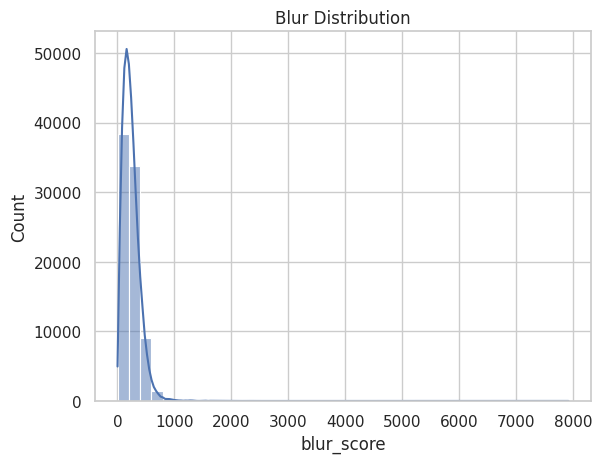

In [ ]:
# --- 1. The Multiprocessing CPU Loader ---
class BlurDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = str(row['file'])
        try:
            # Load image as grayscale ('L') and resize to a uniform size
            # so they can be stacked cleanly into tensors
            img = Image.open(path).convert('L').resize((256, 256))

            # Convert to a floating point tensor scaled between 0 and 1
            img_tensor = torch.tensor(np.array(img), dtype=torch.float32) / 255.0
            return img_tensor.unsqueeze(0), path, "valid"
        except Exception as e:
            # Return dummy tensor if the file is corrupted
            return torch.zeros((1, 256, 256)), path, f"Error: {e}"

# --- 2. The GPU Laplacian Calculator ---
def calculate_blur_gpu(train_df, batch_size=64, num_workers=4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running pipeline on: {device.type.upper()}")

    # Define the 3x3 Laplacian kernel matrix
    laplacian_kernel = torch.tensor([[0,  1, 0],
                                     [1, -4, 1],
                                     [0,  1, 0]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    dataset = BlurDataset(train_df)
    # num_workers fires up background CPU threads to stream images into memory
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    results = {}

    for batch_tensors, batch_paths, batch_statuses in tqdm(loader, desc="GPU Blur Batch Processing"):
        # Filter out corrupted files before pushing to GPU
        valid_indices = [i for i, status in enumerate(batch_statuses) if status == "valid"]

        if not valid_indices:
            for path in batch_paths:
                results[path] = None
            continue

        # Isolate valid tensors and paths
        tensors = batch_tensors[valid_indices].to(device)
        paths = [batch_paths[i] for i in valid_indices]

        with torch.no_grad():
            # Run 2D convolution using our Laplacian kernel across the entire batch at once
            edge_maps = F.conv2d(tensors, laplacian_kernel, padding=1)

            # Calculate the variance for every single image inside the batch matrix
            # Variance = Mean of Squares - Square of Means
            means = torch.mean(edge_maps, dim=(1, 2, 3))
            mean_squares = torch.mean(edge_maps ** 2, dim=(1, 2, 3))
            variances = mean_squares - (means ** 2)

            # Scale the variance back up to match OpenCV scaling conventions
            scaled_variances = variances * (255.0 ** 2)
            scores = scaled_variances.cpu().numpy()

        # Map scores to paths
        for path, score in __builtins__.zip(paths, scores):
            results[path] = score

        # Log None for the failures
        for i, status in enumerate(batch_statuses):
            if status != "valid":
                results[batch_paths[i]] = None

    # Map the results dictionary back into the exact order of the original dataframe
    return [results.get(str(p), None) for p in train_df['file']]

train_df['blur_score'] = calculate_blur_gpu(train_df, batch_size=64, num_workers=4)

# Plot results
sns.histplot(train_df['blur_score'].dropna(), bins=40, kde=True)
plt.title("Blur Distribution")
plt.show()

In [ ]:
test_df['blur_score'] = calculate_blur_gpu(test_df, batch_size=64, num_workers=4)

Running pipeline on: CUDA


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


GPU Blur Batch Processing:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
threshold = train_df['blur_score'].quantile(0.10)
train_df = train_df[train_df['blur_score'] > threshold]

threshold = test_df['blur_score'].quantile(0.10)
test_df = test_df[test_df['blur_score'] > threshold]

## Reducing some of 20-29 and 30-39 age groups to balance classes

In [ ]:
# 1. Isolate the two target groups and the rest of the dataset
age_20s_df = train_df[train_df['age'] == '20-29']
age_30s_df = train_df[train_df['age'] == '30-39']

# Use the tilde (~) to select everything that is NOT in those two groups
rest_of_df = train_df[~train_df['age'].isin(['20-29', '30-39'])]

# 2. Randomly sample exactly 10,000 records from each target group
# random_state ensures the exact same images are dropped every time you run this cell
age_20s_downsampled = age_20s_df.sample(n=10000, random_state=42)
age_30s_downsampled = age_30s_df.sample(n=10000, random_state=42)

# 3. Recombine all the pieces and shuffle the final dataset
train_df = pd.concat([rest_of_df, age_20s_downsampled, age_30s_downsampled])

# Shuffle the rows so the newly added batches aren't all stuck at the bottom
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# --- Verification ---
print("New Age Category Counts:")
print(train_df['age'].value_counts())

New Age Category Counts:
age
30-39           10000
20-29           10000
40-49            9491
3-9              9397
10-19            8006
50-59            5683
60-69            2551
more than 70      756
Name: count, dtype: int64


## Saving pre-processed data

In [ ]:
train_df.to_csv("drive/MyDrive/ff_train.csv", index=False)
test_df.to_csv("drive/MyDrive/ff_test.csv", index=False)

# Load Pre-Processed Data

In [ ]:
file_name = "drive/MyDrive/Fairface.zip"

with ZipFile(file_name, 'r') as zip_file:
  zip_file.extractall()
  print('Done')

Done


In [ ]:
train_df = pd.read_csv("drive/MyDrive/ff_train.csv")
test_df = pd.read_csv("drive/MyDrive/ff_test.csv")

In [ ]:
adult_brackets = ['20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']

# 2. Use .isin() to instantly flag them (1 for over 20, 0 for under 20)
train_df['over_20'] = train_df['age'].isin(adult_brackets).astype(int)
test_df['over_20'] = test_df['age'].isin(adult_brackets).astype(int)
# --- Verification ---
print("Value Counts for Over_20 (1=Adult, 0=Minor):")
print(train_df['over_20'].value_counts())

# Cross-tabulate to prove the split is perfectly clean
print("\nCross-tabulation check:")
print(pd.crosstab(train_df['age'], train_df['over_20']))

Value Counts for Over_20 (1=Adult, 0=Minor):
over_20
1    38481
0    17403
Name: count, dtype: int64

Cross-tabulation check:
over_20          0      1
age                      
10-19         8006      0
20-29            0  10000
3-9           9397      0
30-39            0  10000
40-49            0   9491
50-59            0   5683
60-69            0   2551
more than 70     0    756


In [ ]:

train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

train_df.head()

,file,age,gender,race,service_test,over_20,blur_score
28130,FairFace/train/78457.jpg,50-59,Male,Black,True,1,154.71184
32616,FairFace/train/72321.jpg,20-29,Female,Indian,False,1,126.26272
22034,FairFace/train/23906.jpg,20-29,Male,Middle Eastern,True,1,306.64233
30263,FairFace/train/61931.jpg,40-49,Male,Southeast Asian,False,1,135.90002
47418,FairFace/train/18400.jpg,20-29,Female,East Asian,True,1,611.77936


# Exploratory Data Analysis

## Plot of balanced pre-processed dataset

/tmp/ipykernel_1098/728667717.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='gender', palette='pastel', ax=axes[1])
/tmp/ipykernel_1098/728667717.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='race', order=race_order, palette='Set2', ax=axes[2])


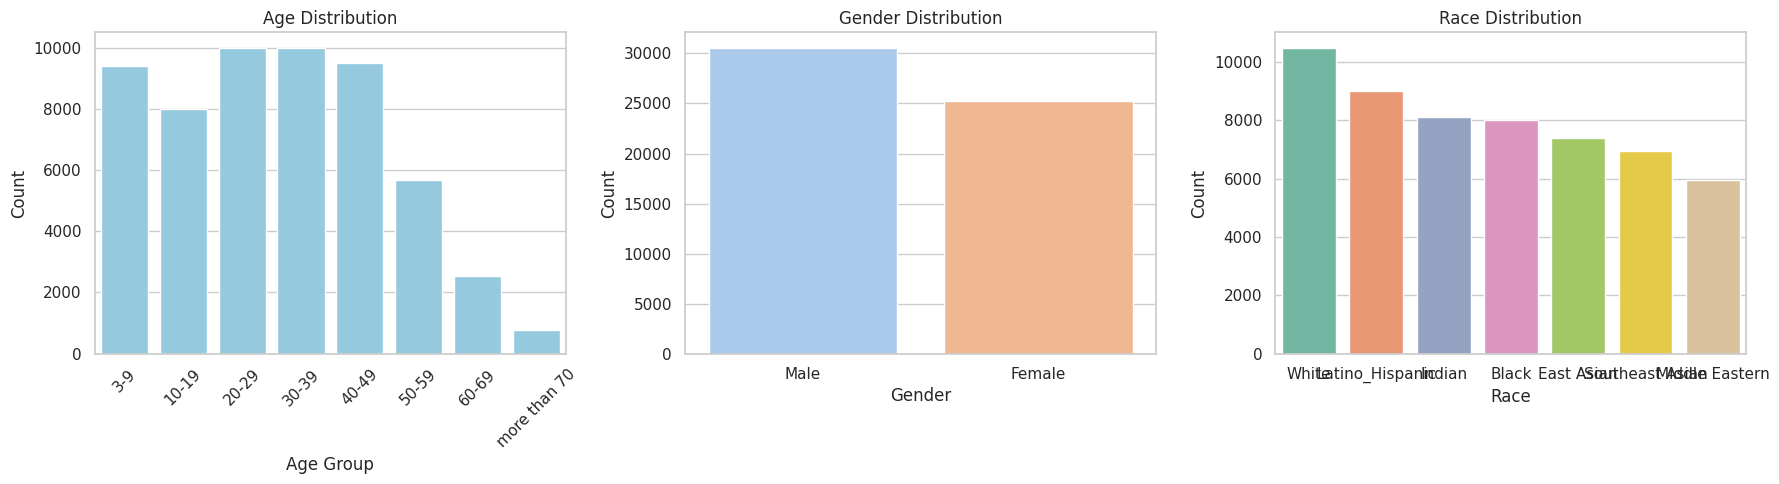

In [ ]:

# 2. Set the visual style for the charts
sns.set_theme(style="whitegrid")

# 3. Create a wide canvas with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Age Distribution ---
# For age, a histogram is better than a standard bar chart because
# it groups the ages into 'bins' rather than plotting 100 individual tiny bars.
order = ['3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']
# 2. Use countplot and inject the order parameter
sns.countplot(
    data=train_df,
    x='age',     # Ensure you are pointing to your grouped column, not raw age
    color='skyblue',
    ax=axes[0],
    order=order # <-- This locks the x-axis order
)

axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')

# 3. Optional but highly recommended: Rotate the text so the labels don't overlap
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Gender Distribution ---
sns.countplot(data=train_df, x='gender', palette='pastel', ax=axes[1])
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

# --- Plot 3: Race Distribution ---
# We order the bars by value counts so the chart looks organized
race_order = train_df['race'].value_counts().index
sns.countplot(data=train_df, x='race', order=race_order, palette='Set2', ax=axes[2])
axes[2].set_title('Race Distribution')
axes[2].set_xlabel('Race')
axes[2].set_ylabel('Count')

# 4. Adjust the spacing and display the plot
plt.tight_layout()
plt.show()

## Plot of Age Groups by Race

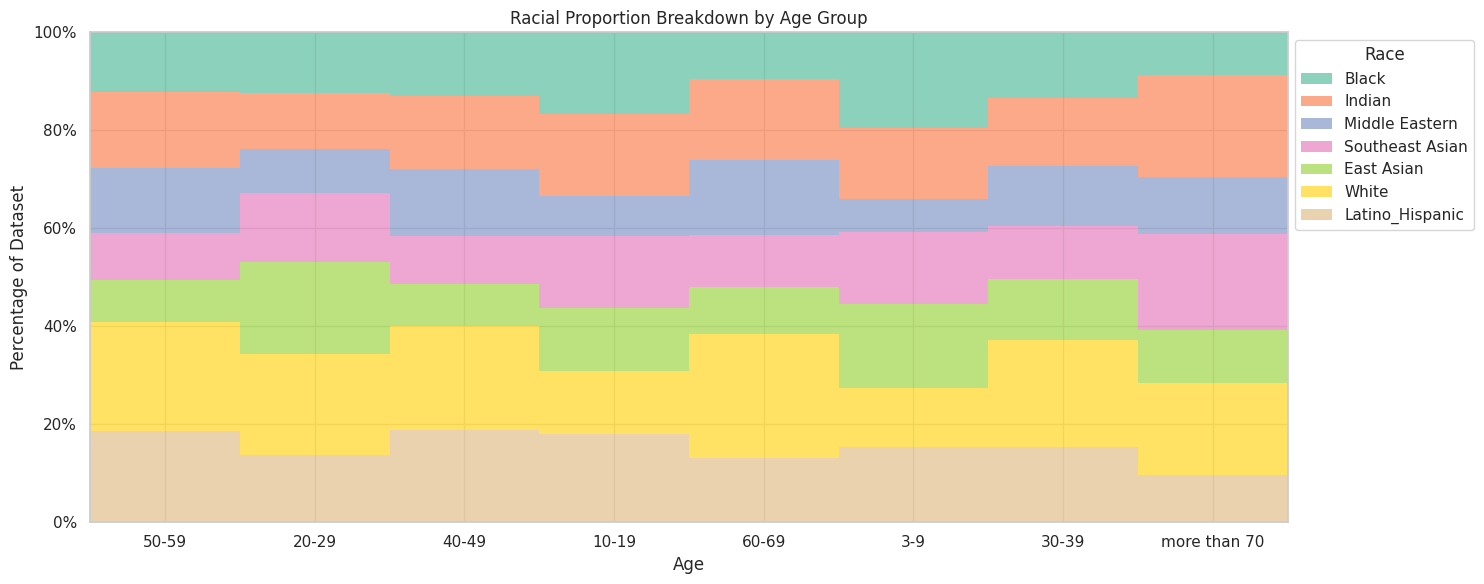

In [ ]:
from matplotlib.ticker import PercentFormatter


# Set the visual style
sns.set_theme(style="whitegrid")

# Create a wide canvas
plt.figure(figsize=(15, 6))

# The magic is in `multiple='fill'`, which forces every bar to stretch exactly to 100%
# discrete=True ensures we get exactly one column for every year of age
ax = sns.histplot(
    data=train_df,
    x='age',
    hue='race',
    multiple='fill',
    discrete=True,
    palette='Set2',
    linewidth=0 # Removes borders between the blocks for a cleaner look
)

plt.title('Racial Proportion Breakdown by Age Group')
plt.xlabel('Age')
plt.ylabel('Percentage of Dataset')

# Format the Y-axis to show percentages (0% to 100%) instead of decimals (0.0 to 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1))

# Move the legend safely outside the plot area so it doesn't cover your data
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Race')

plt.tight_layout()
plt.show()

## Checking image dimensions

In [ ]:
def analyze_dimensions(image_paths):
    print(f"Scanning {len(image_paths)} images (Read-Only)...")

    resolutions = []
    corrupted_count = 0

    for path in image_paths:
        if not os.path.exists(path):
            corrupted_count += 1
            continue

        try:
            # Image.open lazily reads just the header metadata, not the pixels
            with Image.open(path) as img:
                resolutions.append(img.size) # returns a tuple: (width, height)
        except Exception:
            corrupted_count += 1

    # 1. Error Reporting
    if corrupted_count > 0:
        print(f"⚠️ Could not read {corrupted_count} files (missing or corrupted).")

    if not resolutions:
        print("No valid images found to analyze.")
        return

    # 2. Resolution Summary
    res_counts = Counter(resolutions)

    print("\n--- Image Resolution Report ---")
    if len(res_counts) == 1:
        w, h = resolutions[0]
        print(f"✅ Perfect uniformity! All images are exactly {w}x{h}.")
    else:
        print(f"⚠️ Found {len(res_counts)} different image sizes.")

        print("\nTop 5 Most Common Sizes (Width x Height):")
        for (w, h), count in res_counts.most_common(5):
            print(f"  - {w}x{h} px : {count} images")

        # 3. Extremes
        widths = [r[0] for r in resolutions]
        heights = [r[1] for r in resolutions]

        print("\n--- Dimension Extremes ---")
        print(f"Widths:  Min = {min(widths)} px  |  Max = {max(widths)} px")
        print(f"Heights: Min = {min(heights)} px  |  Max = {max(heights)} px")


analyze_dimensions(train_df['file'].tolist())

Scanning 55884 images (Read-Only)...

--- Image Resolution Report ---
✅ Perfect uniformity! All images are exactly 224x224.


# Deep Learning Models

## Dataset Class

In [ ]:
class FairFaceDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

        # Standard ImageNet preprocessing pipeline
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load the cropped image
        img_path = str(row['file'])
        img = Image.open(img_path).convert('RGB')

        # Apply transforms
        img_tensor = self.transform(img)
        over_20 = int(row['over_20'])


        # Convert to a float tensor for BCEWithLogitsLoss compatibility
        target_tensor = torch.tensor(over_20, dtype=torch.float32)

        return img_tensor, target_tensor

## ResNet34

In [ ]:
class Over20ResNet34(nn.Module):
    def __init__(self, dropout=0.4, freeze_backbone=True):
        super().__init__()

        base = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

        # Strip the final FC layer, keep everything up to the avg pool
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # (B, 512, 1, 1)

        if freeze_backbone:
            self.freeze_backbone()

        # Shared neck
        self.neck = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # Binary classification head for over_20
        self.over_20_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1), # Single output node for BCEWithLogitsLoss
        )

        self._init_heads()

    def _init_heads(self):
        for m in [self.neck, self.over_20_head]:
            for layer in m.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self, unfreeze_from_layer=6):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for i, child in enumerate(self.backbone):
            if i >= unfreeze_from_layer:
                for p in child.parameters():
                    p.requires_grad = True

    def forward(self, x):
        x = self.backbone(x).flatten(1)        # (B, 512)
        x = self.neck(x)                       # (B, 256)
        over_20_logit = self.over_20_head(x).squeeze(1) # (B,)
        return over_20_logit

def build_optimiser_phase1(model, lr=2e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

def build_optimiser_phase2(model, lr_backbone=4e-5, lr_heads=2e-4, weight_decay=1e-4):
    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params     = (
        list(model.neck.parameters()) +
        list(model.over_20_head.parameters())
    )
    return torch.optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": head_params,     "lr": lr_heads},
    ], weight_decay=weight_decay)

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0

    for images, over_20 in loader:
        images, over_20 = images.to(device), over_20.to(device)

        optimiser.zero_grad()
        logits = model(images)
        loss = criterion(logits, over_20)
        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_true = [], []

    for images, over_20 in loader:
        images, over_20 = images.to(device), over_20.to(device)

        logits = model(images)
        loss = criterion(logits, over_20)
        total_loss += loss.item()

        # Apply sigmoid to get probabilities between 0 and 1
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_true.extend(over_20.cpu().numpy())

    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc = accuracy_score(all_true, preds)

    # Try/except blocks handle cases where a tiny batch might accidentally
    # contain only one class (all 0s or all 1s), which crashes AUC calculation
    try:
        auc = roc_auc_score(all_true, all_probs)
    except ValueError:
        auc = float('nan')

    return total_loss / len(loader), acc, auc


@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()
    results = []

    # This assumes your test loader yields (images, filenames)
    for images, filenames in loader:
        images = images.to(device)
        logits = model(images)

        probs = torch.sigmoid(logits).cpu().numpy()
        labels = (probs >= 0.5).astype(int)

        for fname, prob, label in zip(filenames, probs, labels):
            results.append({
                "file": fname,
                "pred_over_20": int(label),
                "probability": round(float(prob), 4),
            })

    return pd.DataFrame(results)

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 64    # Adjusted for typical ResNet34 VRAM usage
PHASE1_EPOCHS = 20    # frozen backbone
PHASE2_EPOCHS = 50    # unfrozen top half
DROPOUT       = 0.4
PATIENCE      = 3
UNFREEZE_FROM = 6     # Unfreeze ResNet34 layer3 and layer4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH     = "best_over18_resnet34.pt"

print(f"Device: {DEVICE}")

# ── Datasets & loaders ──────────────────────────────────────────────
# Using the split dataframes from your previous script
train_ds = FairFaceDataset(train_df)
val_ds   = FairFaceDataset(val_df)
test_ds  = FairFaceDataset(test_df) # You can swap this with test_uk_df later

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Model & Loss ─────────────────────────────────────────────────────
model_rn = Over20ResNet34(dropout=DROPOUT, freeze_backbone=True).to(DEVICE)

num_positives = len(train_df[train_df['over_20'] == True])
num_negatives = len(train_df[train_df['over_20'] == False])

# 2. Calculate the ratio (Negatives / Positives)
# In your case, this will equal roughly 14.1
weight_ratio = num_negatives / num_positives

print(f"Adult Positional Weight: {weight_ratio:.2f}")

# 3. Convert to a float tensor and push to the exact same device as your model
pos_weight_tensor = torch.tensor([weight_ratio], dtype=torch.float32).to(DEVICE)

# 4. Inject into the loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# ── Phase 1: Train classification head only ───────────────────────────
print("\n" + "="*60)
print("PHASE 1 — Backbone frozen, training head only")
print("="*60)

optimiser = build_optimiser_phase1(model_rn, lr=4e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=PHASE1_EPOCHS)
best_val_loss = float("inf")
patience_ctr  = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss       = train_one_epoch(model_rn, train_loader, optimiser, criterion, DEVICE)
    val_loss, acc, auc = evaluate(model_rn, val_loader, criterion, DEVICE)
    scheduler.step()

    print(
        f"[P1] Epoch {epoch:03d}/{PHASE1_EPOCHS} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {acc:.3f} | AUC: {auc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model_rn.state_dict(), SAVE_PATH)
        print(f"  -> Checkpoint saved (val_loss={val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ── Phase 2: Unfreeze top backbone blocks ─────────────────────────────
print("\n" + "="*60)
print(f"PHASE 2 — Unfreezing backbone from layer {UNFREEZE_FROM}, fine-tuning")
print("="*60)

# Start Phase 2 from the best weights found in Phase 1
model_rn.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model_rn.unfreeze_backbone(unfreeze_from_layer=UNFREEZE_FROM)

trainable = sum(p.numel() for p in model_rn.parameters() if p.requires_grad)
print(f"Trainable params in phase 2: {trainable:,}")

optimiser = build_optimiser_phase2(model_rn, lr_backbone=3e-5, lr_heads=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
best_val_loss = float("inf")
patience_ctr  = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss       = train_one_epoch(model_rn, train_loader, optimiser, criterion, DEVICE)
    val_loss, acc, auc = evaluate(model_rn, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    print(
        f"[P2] Epoch {epoch:03d}/{PHASE2_EPOCHS} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {acc:.3f} | AUC: {auc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model_rn.state_dict(), SAVE_PATH)
        print(f"  -> Checkpoint saved (val_loss={val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 185MB/s]


Adult Positional Weight: 0.45

PHASE 1 — Backbone frozen, training head only
[P1] Epoch 001/20 | Train Loss: 0.3600 | Val Loss: 0.3168 | Val Acc: 0.696 | AUC: 0.850
  -> Checkpoint saved (val_loss=0.3168)
[P1] Epoch 002/20 | Train Loss: 0.3197 | Val Loss: 0.3102 | Val Acc: 0.812 | AUC: 0.865
  -> Checkpoint saved (val_loss=0.3102)
[P1] Epoch 003/20 | Train Loss: 0.3152 | Val Loss: 0.2805 | Val Acc: 0.790 | AUC: 0.870
  -> Checkpoint saved (val_loss=0.2805)
[P1] Epoch 004/20 | Train Loss: 0.3124 | Val Loss: 0.2873 | Val Acc: 0.785 | AUC: 0.870
[P1] Epoch 005/20 | Train Loss: 0.3071 | Val Loss: 0.2905 | Val Acc: 0.790 | AUC: 0.869
[P1] Epoch 006/20 | Train Loss: 0.3036 | Val Loss: 0.2951 | Val Acc: 0.798 | AUC: 0.871
  Early stopping at epoch 6.

PHASE 2 — Unfreezing backbone from layer 6, fine-tuning
Trainable params in phase 2: 20,084,609
[P2] Epoch 001/50 | Train Loss: 0.2219 | Val Loss: 0.1837 | Val Acc: 0.893 | AUC: 0.953
  -> Checkpoint saved (val_loss=0.1837)
[P2] Epoch 002/50 | T

## DenseNet121

In [ ]:
class Over20DenseNet121(nn.Module):
    def __init__(self, dropout=0.4, freeze_backbone=True):
        super().__init__()

        # 1. Properly target the feature extractor of DenseNet
        base = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        self.backbone = base.features  # Outputs a tensor of shape: (B, 1024, 7, 7)

        if freeze_backbone:
            self.freeze_backbone()

        # 2. Shared neck: Collapses the 3D spatial tensor and steps down channels
        self.neck = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Collapses (7, 7) spatial grid to (1, 1)
            nn.Flatten(),                 # Turns shape from (B, 1024, 1, 1) into (B, 1024)
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # 3. Binary classification head for over_20 (Fixed structural dimensions)
        self.over_20_head = nn.Sequential(
            nn.Linear(512, 128),         # Intermediate step down to 128
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),           # Matches the 128 input dimension -> 1 output
        )

        self._init_heads()

    def _init_heads(self):
        for m in [self.neck, self.over_20_head]:
            for layer in m.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self, unfreeze_from_layer=6):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for i, child in enumerate(self.backbone):
            if i >= unfreeze_from_layer:
                for p in child.parameters():
                    p.requires_grad = True

    def forward(self, x):
        x = self.backbone(x)                   # (B, 1024, H, W)
        x = self.neck(x)                       # (B, 512)
        over_20_logit = self.over_20_head(x).squeeze(1) # (B,)
        return over_20_logit

def build_optimiser_phase1(model, lr=2e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

def build_optimiser_phase2(model, lr_backbone=4e-5, lr_heads=2e-4, weight_decay=1e-4):
    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params     = (
        list(model.neck.parameters()) +
        list(model.over_20_head.parameters())
    )
    return torch.optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": head_params,     "lr": lr_heads},
    ], weight_decay=weight_decay)

def train_one_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0

    for images, over_20 in loader:
        images, over_20 = images.to(device), over_20.to(device)

        optimiser.zero_grad()
        logits = model(images)
        loss = criterion(logits, over_20)
        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_true = [], []

    for images, over_20 in loader:
        images, over_20 = images.to(device), over_20.to(device)

        logits = model(images)
        loss = criterion(logits, over_20)
        total_loss += loss.item()

        # Apply sigmoid to get probabilities between 0 and 1
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())
        all_true.extend(over_20.cpu().numpy())

    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc = accuracy_score(all_true, preds)

    # Try/except blocks handle cases where a tiny batch might accidentally
    # contain only one class (all 0s or all 1s), which crashes AUC calculation
    try:
        auc = roc_auc_score(all_true, all_probs)
    except ValueError:
        auc = float('nan')

    return total_loss / len(loader), acc, auc


@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()
    results = []

    # This assumes your test loader yields (images, filenames)
    for images, filenames in loader:
        images = images.to(device)
        logits = model(images)

        probs = torch.sigmoid(logits).cpu().numpy()
        labels = (probs >= 0.5).astype(int)

        for fname, prob, label in zip(filenames, probs, labels):
            results.append({
                "file": fname,
                "pred_over_20": int(label),
                "probability": round(float(prob), 4),
            })

    return pd.DataFrame(results)

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE    = 64    # Adjusted for typical ResNet34 VRAM usage
PHASE1_EPOCHS = 20    # frozen backbone
PHASE2_EPOCHS = 50    # unfrozen top half
DROPOUT       = 0.4
PATIENCE      = 4
UNFREEZE_FROM = 6     # Unfreeze ResNet34 layer3 and layer4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH     = "best_over18_densenet34.pt"

print(f"Device: {DEVICE}")

# ── Datasets & loaders ──────────────────────────────────────────────
# Using the split dataframes from your previous script
train_ds = FairFaceDataset(train_df)
val_ds   = FairFaceDataset(val_df)
test_ds  = FairFaceDataset(test_df) # You can swap this with test_uk_df later

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Model & Loss ─────────────────────────────────────────────────────
model_rn = Over20DenseNet121(dropout=DROPOUT, freeze_backbone=True).to(DEVICE)

num_positives = len(train_df[train_df['over_20'] == True])
num_negatives = len(train_df[train_df['over_20'] == False])

# 2. Calculate the ratio (Negatives / Positives)
# In your case, this will equal roughly 14.1
weight_ratio = num_negatives / num_positives

print(f"Adult Positional Weight: {weight_ratio:.2f}")

# 3. Convert to a float tensor and push to the exact same device as your model
pos_weight_tensor = torch.tensor([weight_ratio], dtype=torch.float32).to(DEVICE)

# 4. Inject into the loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# ── Phase 1: Train classification head only ───────────────────────────
print("\n" + "="*60)
print("PHASE 1 — Backbone frozen, training head only")
print("="*60)

optimiser = build_optimiser_phase1(model_rn, lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=PHASE1_EPOCHS)
best_val_loss = float("inf")
patience_ctr  = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss       = train_one_epoch(model_rn, train_loader, optimiser, criterion, DEVICE)
    val_loss, acc, auc = evaluate(model_rn, val_loader, criterion, DEVICE)
    scheduler.step()

    print(
        f"[P1] Epoch {epoch:03d}/{PHASE1_EPOCHS} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {acc:.3f} | AUC: {auc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model_rn.state_dict(), SAVE_PATH)
        print(f"  -> Checkpoint saved (val_loss={val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ── Phase 2: Unfreeze top backbone blocks ─────────────────────────────
print("\n" + "="*60)
print(f"PHASE 2 — Unfreezing backbone from layer {UNFREEZE_FROM}, fine-tuning")
print("="*60)

# Start Phase 2 from the best weights found in Phase 1
model_rn.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model_rn.unfreeze_backbone(unfreeze_from_layer=UNFREEZE_FROM)

trainable = sum(p.numel() for p in model_rn.parameters() if p.requires_grad)
print(f"Trainable params in phase 2: {trainable:,}")

optimiser = build_optimiser_phase2(model_rn, lr_backbone=2e-5, lr_heads=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
best_val_loss = float("inf")
patience_ctr  = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss       = train_one_epoch(model_rn, train_loader, optimiser, criterion, DEVICE)
    val_loss, acc, auc = evaluate(model_rn, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    print(
        f"[P2] Epoch {epoch:03d}/{PHASE2_EPOCHS} | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {acc:.3f} | AUC: {auc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model_rn.state_dict(), SAVE_PATH)
        print(f"  -> Checkpoint saved (val_loss={val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

Device: cuda
Adult Positional Weight: 0.45

PHASE 1 — Backbone frozen, training head only
[P1] Epoch 001/30 | Train Loss: 0.3089 | Val Loss: 0.2780 | Val Acc: 0.766 | AUC: 0.879
  -> Checkpoint saved (val_loss=0.2780)
[P1] Epoch 002/30 | Train Loss: 0.2813 | Val Loss: 0.2741 | Val Acc: 0.832 | AUC: 0.887
  -> Checkpoint saved (val_loss=0.2741)
[P1] Epoch 003/30 | Train Loss: 0.2709 | Val Loss: 0.2632 | Val Acc: 0.790 | AUC: 0.891
  -> Checkpoint saved (val_loss=0.2632)
[P1] Epoch 004/30 | Train Loss: 0.2625 | Val Loss: 0.2607 | Val Acc: 0.817 | AUC: 0.891
  -> Checkpoint saved (val_loss=0.2607)
[P1] Epoch 005/30 | Train Loss: 0.2567 | Val Loss: 0.2628 | Val Acc: 0.796 | AUC: 0.894
[P1] Epoch 006/30 | Train Loss: 0.2483 | Val Loss: 0.2558 | Val Acc: 0.815 | AUC: 0.896
  -> Checkpoint saved (val_loss=0.2558)
[P1] Epoch 007/30 | Train Loss: 0.2425 | Val Loss: 0.2623 | Val Acc: 0.819 | AUC: 0.894
[P1] Epoch 008/30 | Train Loss: 0.2338 | Val Loss: 0.2566 | Val Acc: 0.817 | AUC: 0.894
[P1] E

# Evaluations

In [ ]:

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from PIL import Image

# ── 1. BINARY INFERENCE LOOP ─────────────────────────────────────────────
@torch.no_grad()
def evaluate_binary_test_set(model, test_df, device):
    """
    Runs inference on a strict single-logit binary model, computes test metrics,
    and returns a clean DataFrame mapped with all original demographics.
    """
    model.eval()

    # Initialize your binary dataset setup
    test_ds = FairFaceDataset(test_df)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    all_probs = []
    all_true_labels = []

    print("Running final binary inference across the test set...")
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)

        # Check if logits shape is (B, 1) and squeeze to (B,) if necessary
        if len(logits.shape) > 1 and logits.shape[1] == 1:
            logits = logits.squeeze(1)

        # Squish single logit to output probability
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_true_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_true_labels = np.array(all_true_labels)

    # Standard classification threshold
    all_preds = (all_probs >= 0.5).astype(int)

    # ── 2. METRIC CALCULATIONS ───────────────────────────────────────────
    test_acc = accuracy_score(all_true_labels, all_preds)
    test_auc = roc_auc_score(all_true_labels, all_probs)

    print("\n" + "="*50)
    print("             BINARY TEST SET PERFORMANCE          ")
    print("="*50)
    print(f"Test Accuracy:  {test_acc * 100:.2f}%")
    print(f"Test ROC AUC:   {test_auc:.4f}")
    print("="*50)

    print("\nClassification Report:")
    print(classification_report(all_true_labels, all_preds, target_names=['Minor (<20)', 'Adult (>=20)']))

    # ── 3. MARRY PREDICTIONS TO ORIGINAL DEMOGRAPHICS ─────────────────────
    # Create a copy of the test dataframe to safely insert predictions
    audit_df = test_df.copy().reset_index(drop=True)
    audit_df['probability'] = np.round(all_probs, 4)
    audit_df['pred_over_20'] = all_preds

    # Ensure your target columns align perfectly as integers for the upcoming audit functions
    audit_df['over_20'] = audit_df['over_20'].astype(int)

    return audit_df


def calculate_audit_metrics(df, true_col='over_20', pred_col='pred_over_20'):
    """Calculates Accuracy, False Positive Rate (FPR), and False Negative Rate (FNR)."""
    cm = confusion_matrix(df[true_col], df[pred_col], labels=[0, 1])

    # Handle cases where a demographic slice might not have all classes
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        acc = (tp + tn) / (tp + tn + fp + fn)
        # FPR: % of Minors incorrectly labeled as Adults (Critical Failure)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        # FNR: % of Adults incorrectly labeled as Minors (Inconvenience)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    else:
        acc, fpr, fnr = np.nan, np.nan, np.nan

    return pd.Series({'Accuracy': acc, 'FPR (Minors -> Adults)': fpr, 'FNR (Adults -> Minors)': fnr})

def plot_demographic_bar_charts(df, demographic_columns):
    """Plots comparative accuracy and error rates across different demographic groups with sorted age bins."""
    sns.set_theme(style="whitegrid")

    # Define the exact logical sequence of your FairFace age groups
    # Note: '0-2' is omitted here since you dropped it earlier
    age_order = ['3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', 'more than 70']

    for demo_col in demographic_columns:
        # Group by demographic and calculate metrics
        audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()

        # ─── CRITICAL FIX: Sort the demographic groups logically before melting ───
        if demo_col == 'age':
            # Filter the master order list to only include groups actually present in your audit_df
            available_order = [group for group in age_order if group in audit_df['age'].values]

            # Cast to an ordered Categorical type so Pandas/Seaborn sort it logically instead of alphabetically
            audit_df['age'] = pd.Categorical(audit_df['age'], categories=available_order, ordered=True)
            audit_df = audit_df.sort_values('age')
        else:
            # Optional: Alphabetical fallback for race/gender to ensure consistency
            audit_df = audit_df.sort_values(demo_col)

        # Melt DataFrame for Seaborn grouped bar plot
        melted_df = audit_df.melt(id_vars=demo_col, var_name='Metric', value_name='Score')

        plt.figure(figsize=(10, 5))
        sns.barplot(
            data=melted_df,
            x=demo_col,
            y='Score',
            hue='Metric',
            palette=['#2ecc71', '#e74c3c', '#f39c12']
        )

        plt.title(f'Performance Audit Breakdown by {demo_col.capitalize()}', fontsize=14, pad=15)
        plt.ylabel('Rate (0.0 to 1.0)', fontsize=12)
        plt.xlabel(demo_col.capitalize(), fontsize=12)
        plt.ylim(0, 1.05)
        plt.xticks(rotation=45, ha='right')
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

def plot_subgroup_confusion_matrices(df, demographic_col, true_col='over_20', pred_col='pred_over_20'):
    """Generates a grid of confusion matrices for every unique value in a demographic category."""
    subgroups = sorted(df[demographic_col].unique())
    num_groups = len(subgroups)


    # Calculate grid layout dynamically
    cols = 3
    rows = int(np.ceil(num_groups / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    labels = ['Minor (<20)', 'Adult (>=20)']

    for i, group in enumerate(subgroups):
        subset = df[df[demographic_col] == group]
        cm = confusion_matrix(subset[true_col], subset[pred_col], labels=[0, 1])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    cbar=False, ax=axes[i], annot_kws={"size": 12})

        axes[i].set_title(f'{group} (n={len(subset)})', fontsize=12, pad=10)
        axes[i].set_xlabel('Predicted', fontsize=10)
        axes[i].set_ylabel('True', fontsize=10)

    # Hide any unused subplots in the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Confusion Matrices Stratified by {demographic_col.capitalize()}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()



## ResNet34

In [ ]:
results_df = evaluate_binary_test_set(model_rn, test_df, device=DEVICE)

# Save the predictions to disk
results_df.to_csv("rn_evaluation.csv", index=False)
print("\nEvaluation complete! Matrix data exported to 'binary_test_audit_input.csv'")

Running final binary inference across the test set...

             BINARY TEST SET PERFORMANCE          
Test Accuracy:  83.28%
Test ROC AUC:   0.9368

Classification Report:
              precision    recall  f1-score   support

 Minor (<20)       0.60      0.89      0.72      2273
Adult (>=20)       0.96      0.82      0.88      7169

    accuracy                           0.83      9442
   macro avg       0.78      0.85      0.80      9442
weighted avg       0.87      0.83      0.84      9442


Evaluation complete! Matrix data exported to 'binary_test_audit_input.csv'


Generating Bar Charts...


/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


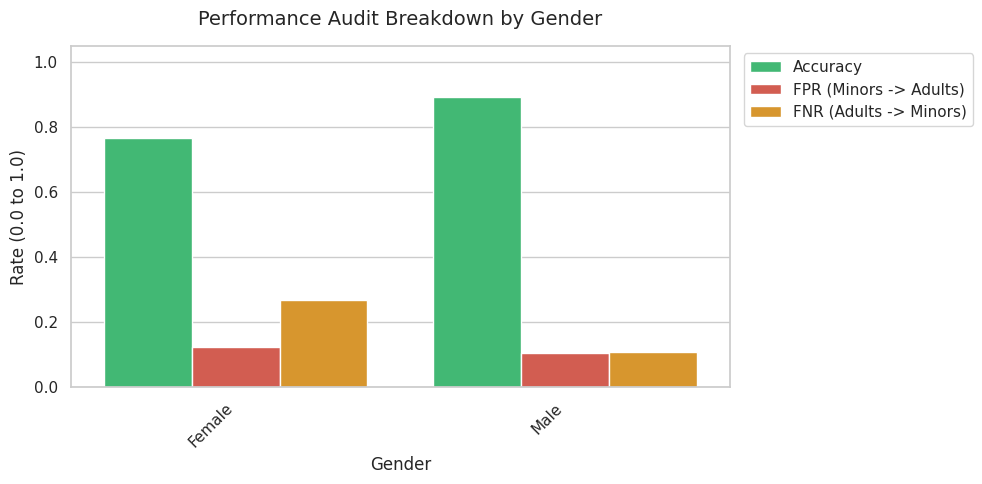

/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


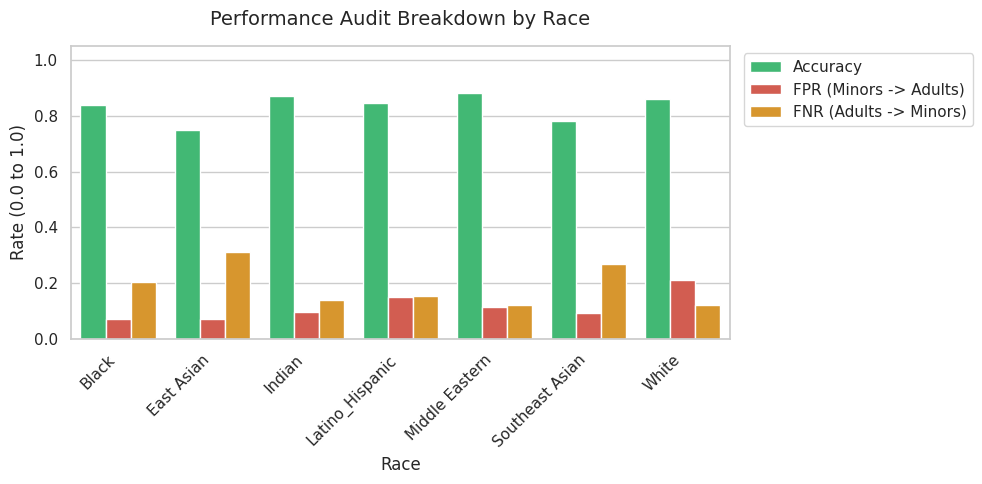

/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


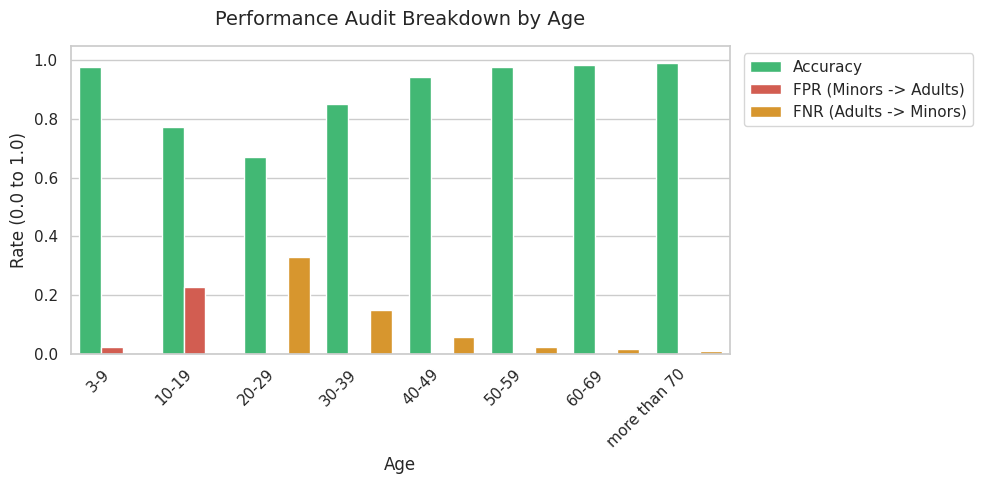


Generating Stratified Confusion Matrices...


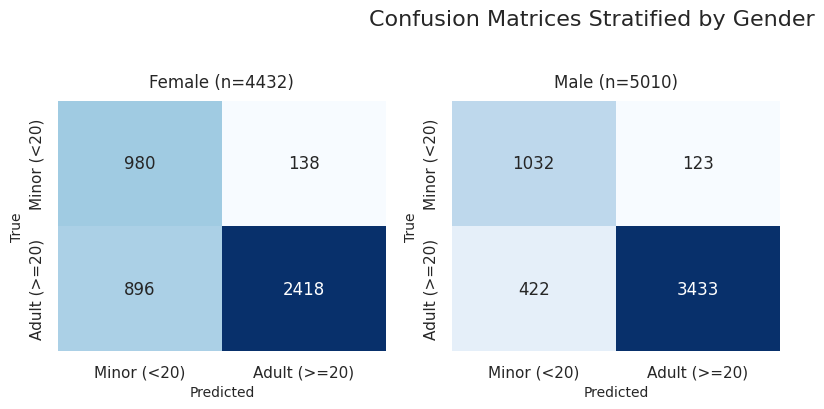

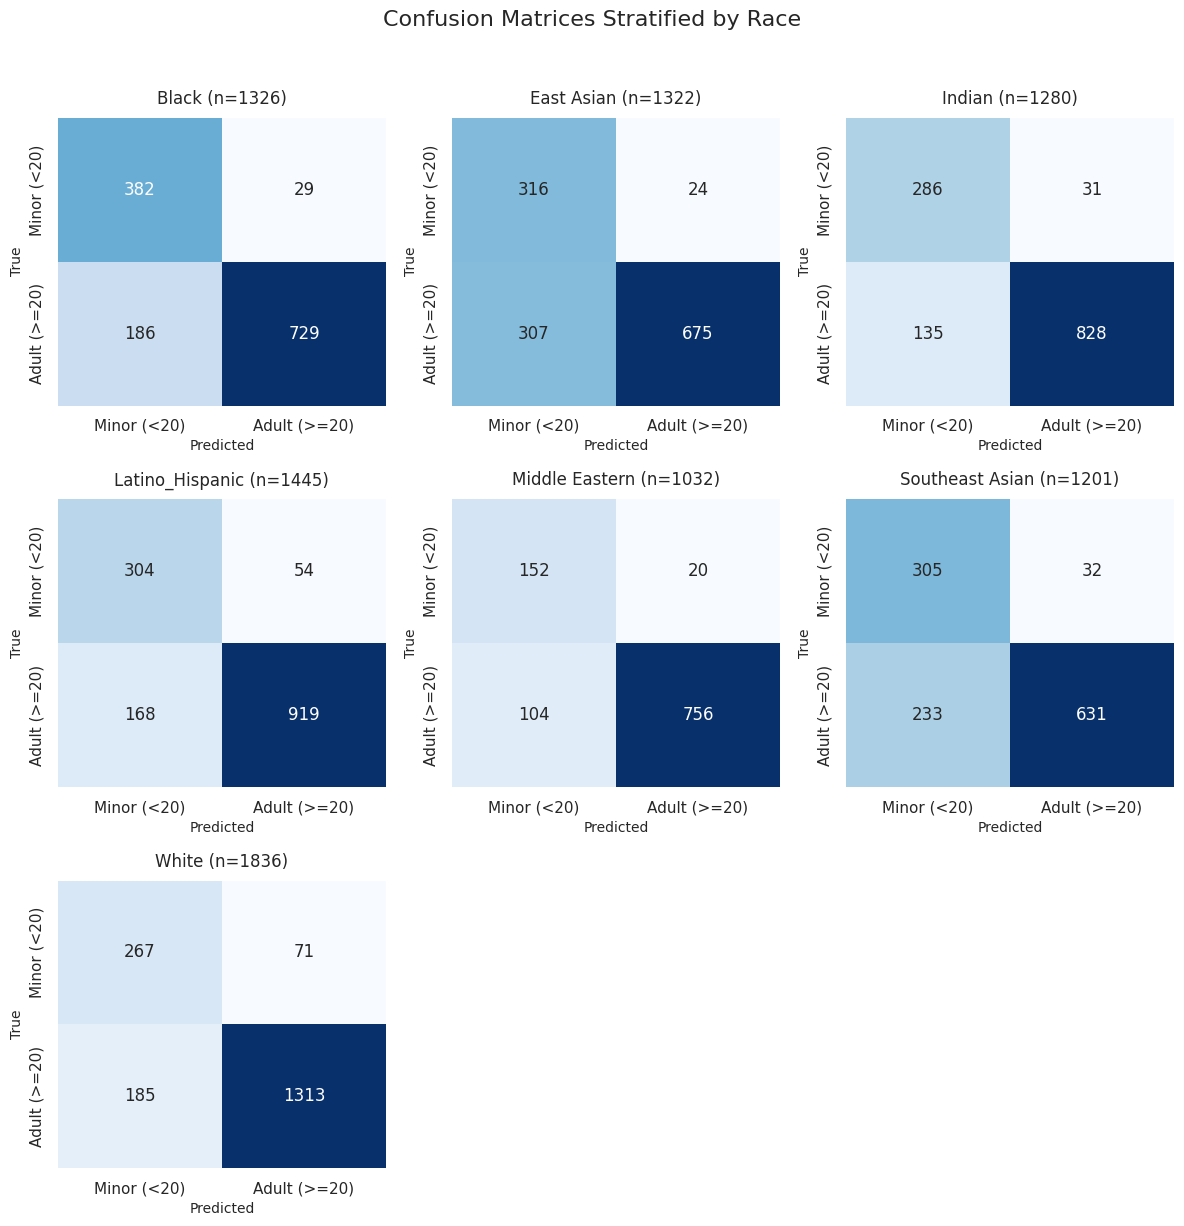

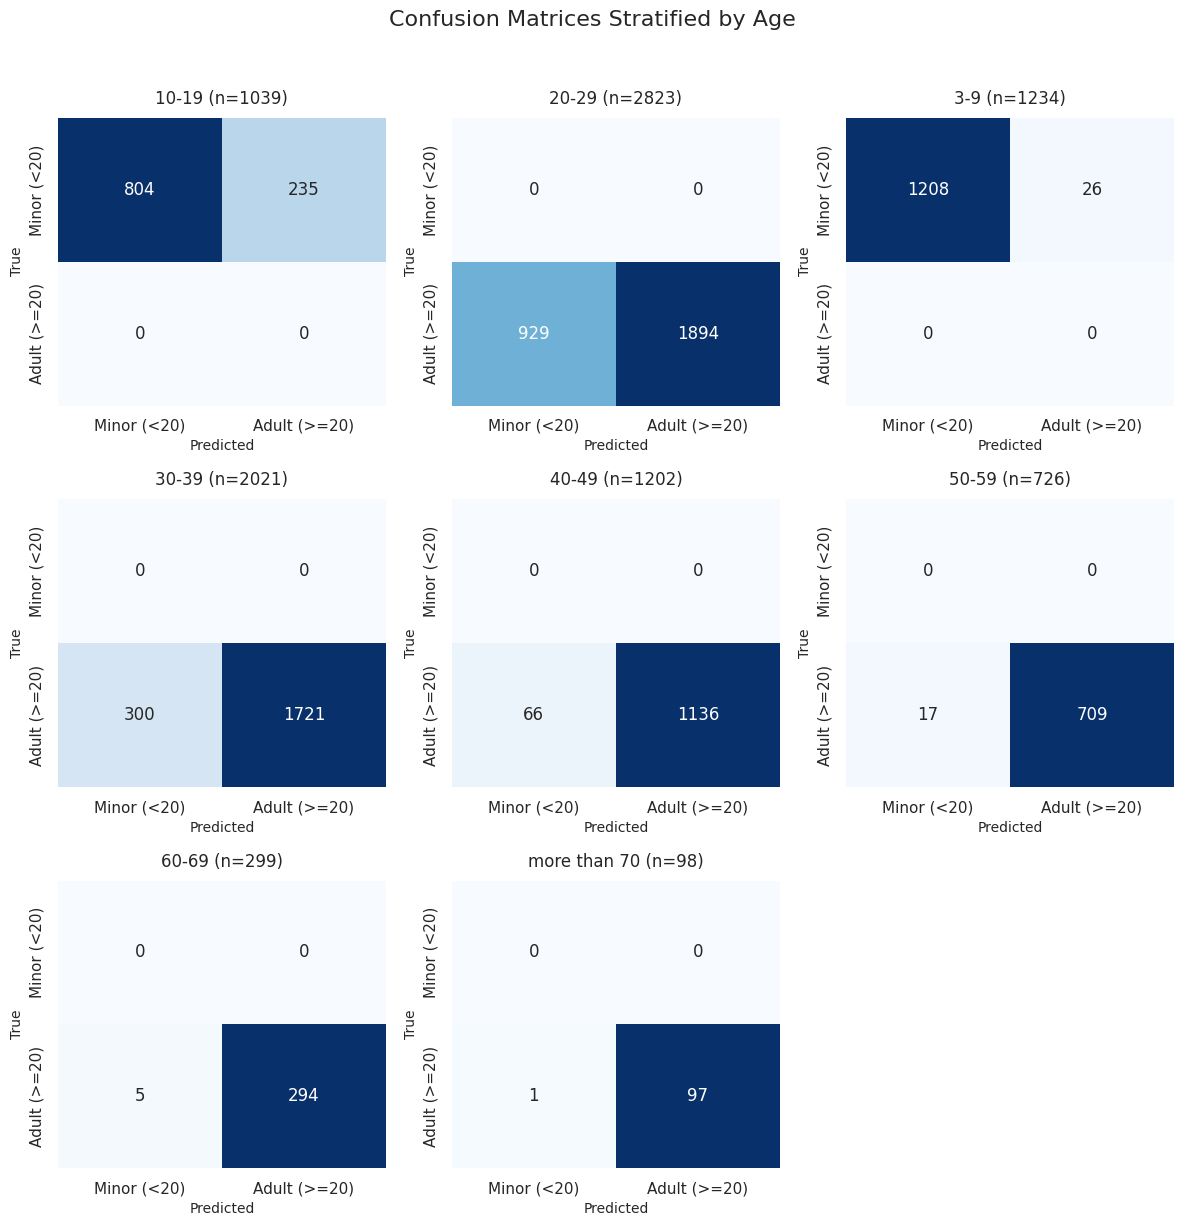

In [ ]:
# ─── Execution ────────────────────────────────────────────────────────
# Assuming 'results_df' is your DataFrame containing test set predictions
demographics_to_audit = ['gender', 'race', 'age']

print("Generating Bar Charts...")
plot_demographic_bar_charts(results_df, demographics_to_audit)

print("\nGenerating Stratified Confusion Matrices...")
for demo in demographics_to_audit:
    plot_subgroup_confusion_matrices(results_df, demographic_col=demo)

In [ ]:
def generate_ethnicity_stats_table(df):
    """
    Generates a structured summary table showing Accuracy, FPR, and FNR
    broken down by ethnicity.
    """
    # Map numerical race codes to text labels if they aren't already string values
    race_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Other'}

    # Ensure working vectors are cleanly isolated
    y_true = df['over_20'].astype(int).values
    y_pred = df['pred_over_20'].astype(int).values
    r_labels = df['race'].map(race_map).fillna(df['race']).values

    stats_list = []
    unique_races = np.unique(r_labels)

    for race in unique_races:
        mask = (r_labels == race)
        if mask.sum() == 0:
            continue

        y_true_sub = y_true[mask]
        y_pred_sub = y_pred[mask]

        # Extract confusion matrix components safely
        # Labels=[0, 1] maps 0 to Minor and 1 to Adult
        tn, fp, fn, tp = confusion_matrix(y_true_sub, y_pred_sub, labels=[0, 1]).ravel()

        # Calculate Rates
        total = tn + fp + fn + tp
        accuracy = (tp + tn) / total if total > 0 else 0

        # False Positive Rate: Minors incorrectly flagged as Adults
        fpr = fp / (tn + fp) if (tn + fp) > 0 else 0

        # False Negative Rate: Adults incorrectly flagged as Minors
        fnr = fn / (tp + fn) if (tp + fn) > 0 else 0

        stats_list.append({
            'Ethnicity': race,
            'Sample Size (n)': int(total),
            'Accuracy (%)': round(accuracy * 100, 2),
            'FPR: Minor as Adult (%)': round(fpr * 100, 2),
            'FNR: Adult as Minor (%)': round(fnr * 100, 2)
        })

    # Convert list to structured Pandas DataFrame
    summary_table = pd.DataFrame(stats_list)
    return summary_table

# ─── Execution Pass ─────────────────────────────────────────────────────
# Pass your test results dataframe into the function
ethnicity_audit_df = generate_ethnicity_stats_table(results_df)

# Display the clean markdown table representation directly in your notebook
from IPython.display import display, HTML
print("                                 ResNet34 Stats by Ethnicity")
display(HTML(ethnicity_audit_df.to_html(index=False)))

                                 ResNet34 Stats by Ethnicity


Ethnicity,Sample Size (n),Accuracy (%),FPR: Minor as Adult (%),FNR: Adult as Minor (%)
Black,1326,83.79,7.06,20.33
East Asian,1322,74.96,7.06,31.26
Indian,1280,87.03,9.78,14.02
Latino_Hispanic,1445,84.64,15.08,15.46
Middle Eastern,1032,87.98,11.63,12.09
Southeast Asian,1201,77.94,9.50,26.97
White,1836,86.06,21.01,12.35


<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_849/4182421584.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('Predicted Probability of Being an Adult ($\geq 20$)', fontsize=12)
/tmp/ipykernel_849/4182421584.py:44: SyntaxWarning: invalid escape sequence '\g'
  labels = ['Minor ($< 20$)', 'Adult ($\geq 20$)']


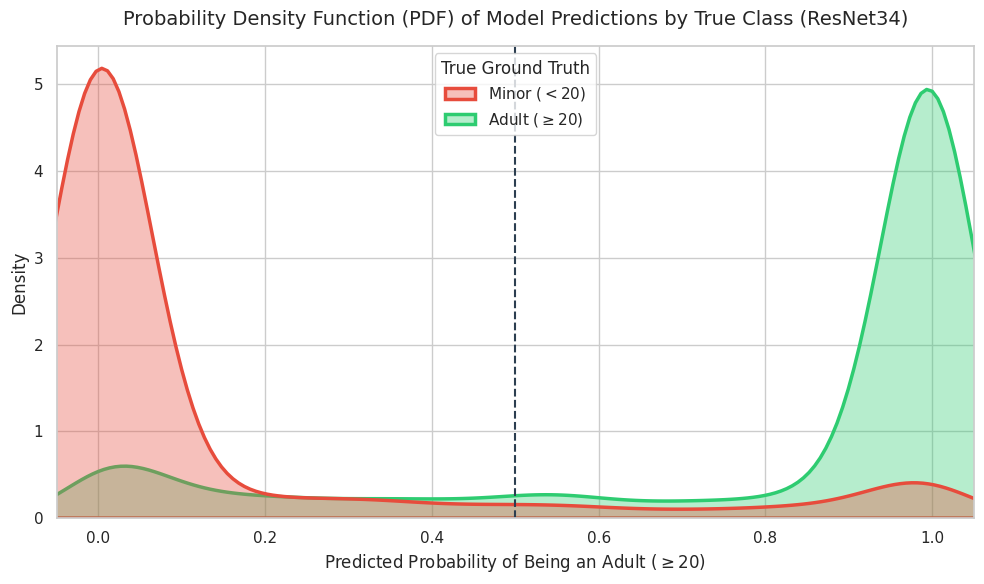

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.read_csv('drive/MyDrive/rn_evaluation.csv')
# 1. Set the aesthetic theme
sns.set_theme(style="whitegrid")

# 2. Set up the canvas using subplots
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot the continuous probability density distributions
# 'common_norm=False' normalizes each class independently so sample size imbalances don't distort the curves
sns.kdeplot(
    data=results_df,
    x='probability',
    hue='over_20',
    fill=True,
    common_norm=False,
    palette=['#e74c3c', '#2ecc71'],
    alpha=0.35,
    linewidth=2.5,
    ax=ax
)

# 4. Add a vertical line at the default classification threshold
ax.axvline(
    x=0.5,
    color='#2c3e50',
    linestyle='--',
    linewidth=1.5,
    label='Classification Threshold ($0.5$)'
)

# 5. Scientific formatting and labeling
ax.set_title('Probability Density Function (PDF) of Model Predictions by True Class (ResNet34)', fontsize=14, pad=15)
ax.set_xlabel('Predicted Probability of Being an Adult ($\geq 20$)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-0.05, 1.05)

# Update legend text safely to show clear human-readable categories
leg = ax.get_legend()
if leg:
    leg.set_title('True Ground Truth')
    labels = ['Minor ($< 20$)', 'Adult ($\geq 20$)']
    for t, label in zip(leg.texts, labels):
        t.set_text(label)

plt.tight_layout()

# 6. Save the graphic locally
plt.savefig('probability_density_plot.png', dpi=300, bbox_inches='tight')

##DenseNet

In [ ]:
results_df = evaluate_binary_test_set(model_rn, test_df, device=DEVICE)

# Save the predictions to disk
results_df.to_csv("dn_evaluation.csv", index=False)
print("\nEvaluation complete! Matrix data exported to 'binary_test_audit_input.csv'")

Running final binary inference across the test set...

             BINARY TEST SET PERFORMANCE          
Test Accuracy:  85.68%
Test ROC AUC:   0.9261

Classification Report:
              precision    recall  f1-score   support

 Minor (<20)       0.67      0.81      0.73      2273
Adult (>=20)       0.94      0.87      0.90      7169

    accuracy                           0.86      9442
   macro avg       0.80      0.84      0.82      9442
weighted avg       0.87      0.86      0.86      9442


Evaluation complete! Matrix data exported to 'binary_test_audit_input.csv'


Generating Bar Charts...


/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


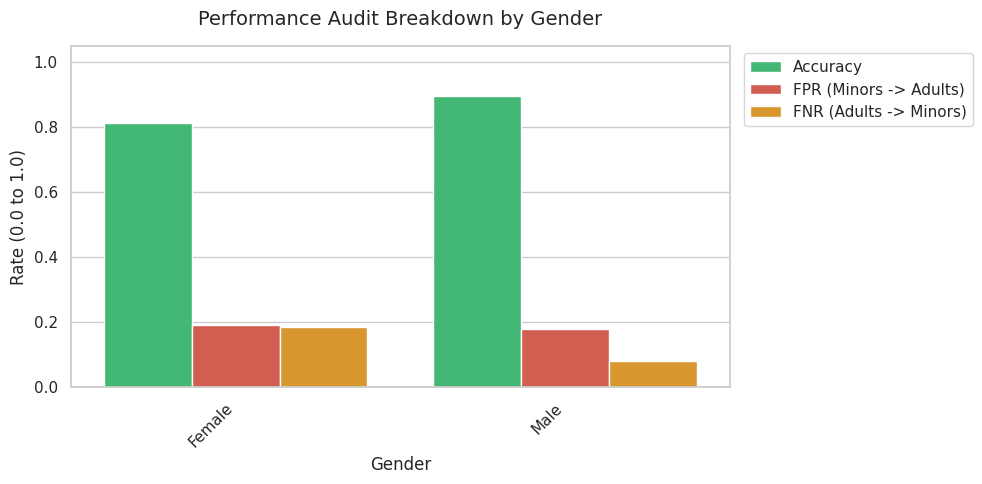

/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


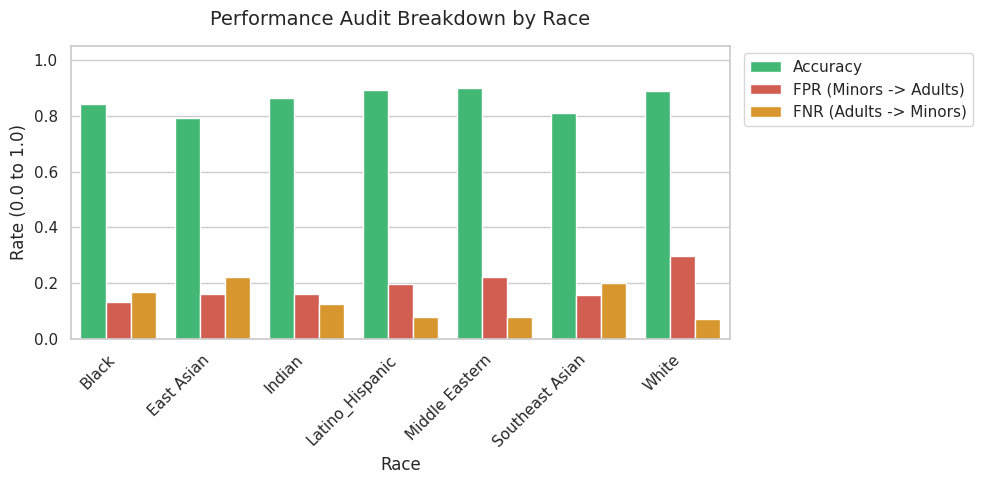

/tmp/ipykernel_849/122168685.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit_df = df.groupby(demo_col).apply(calculate_audit_metrics).reset_index()


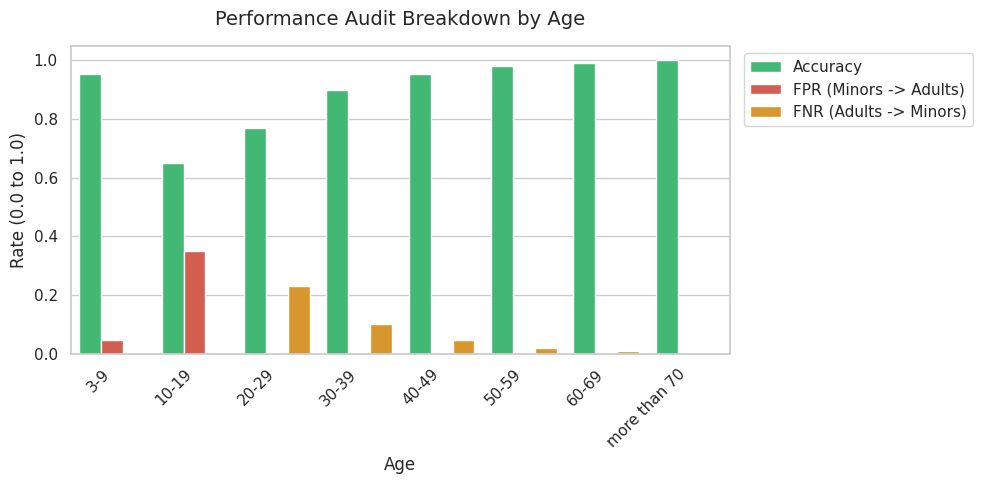


Generating Stratified Confusion Matrices...


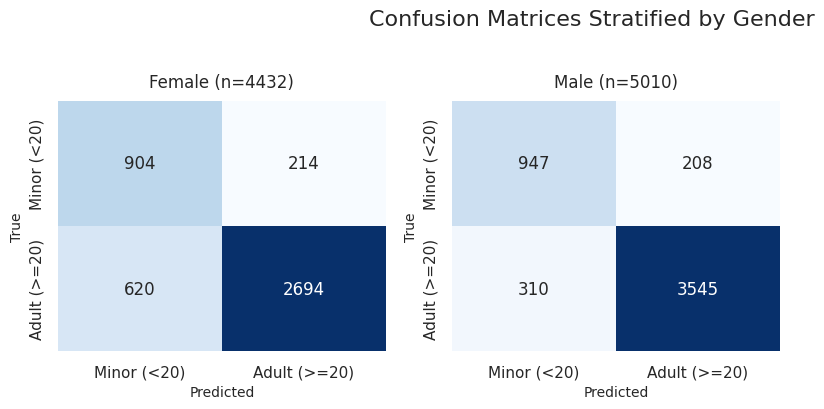

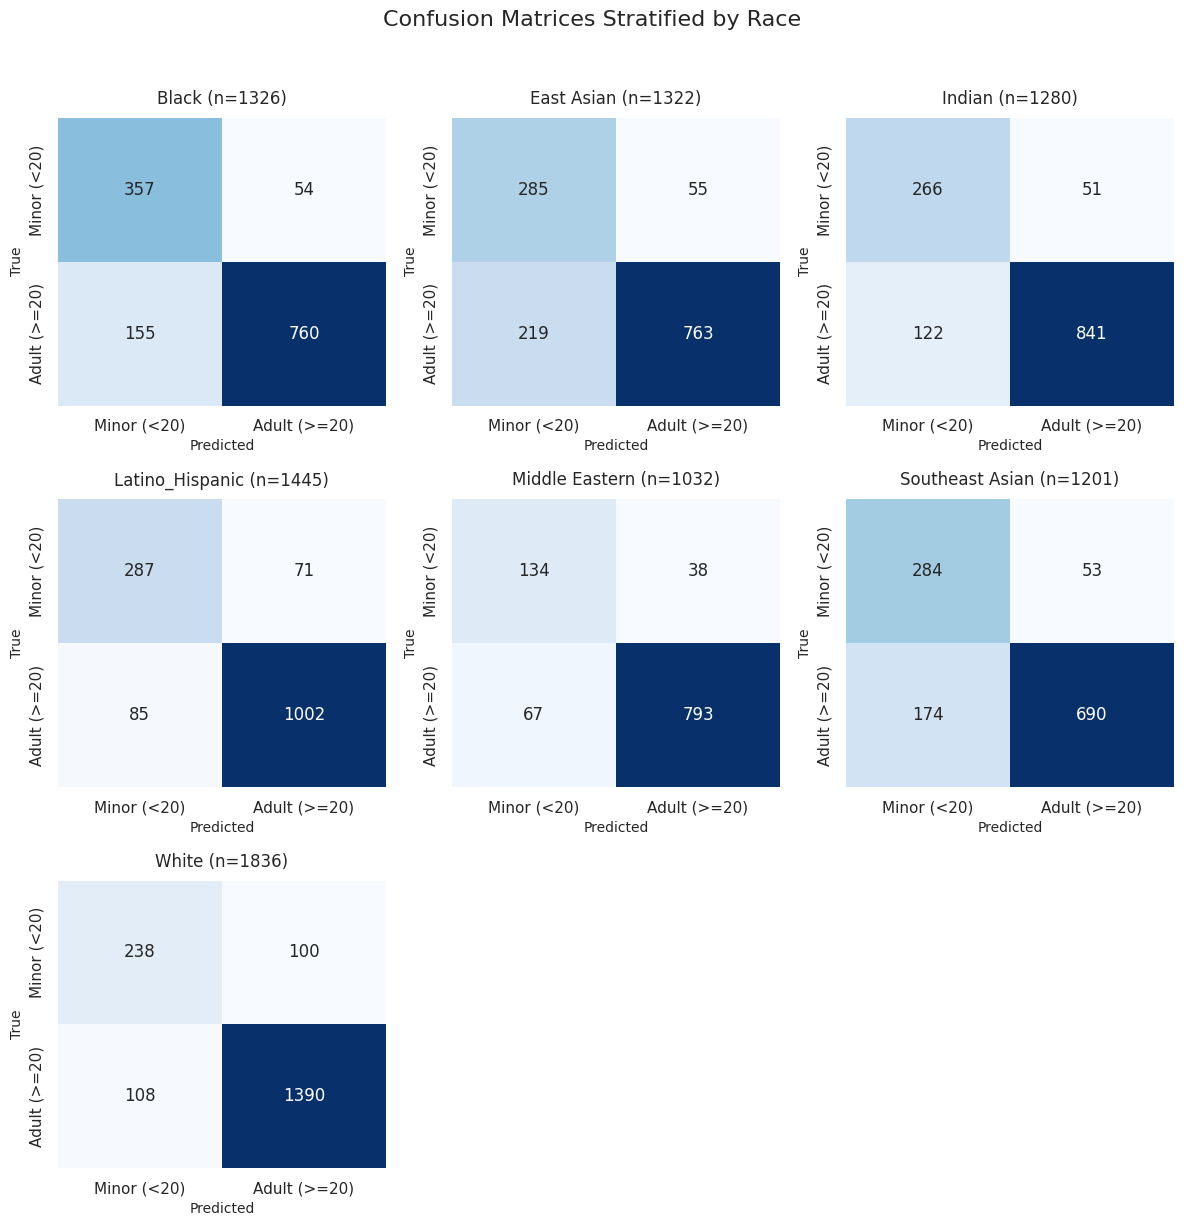

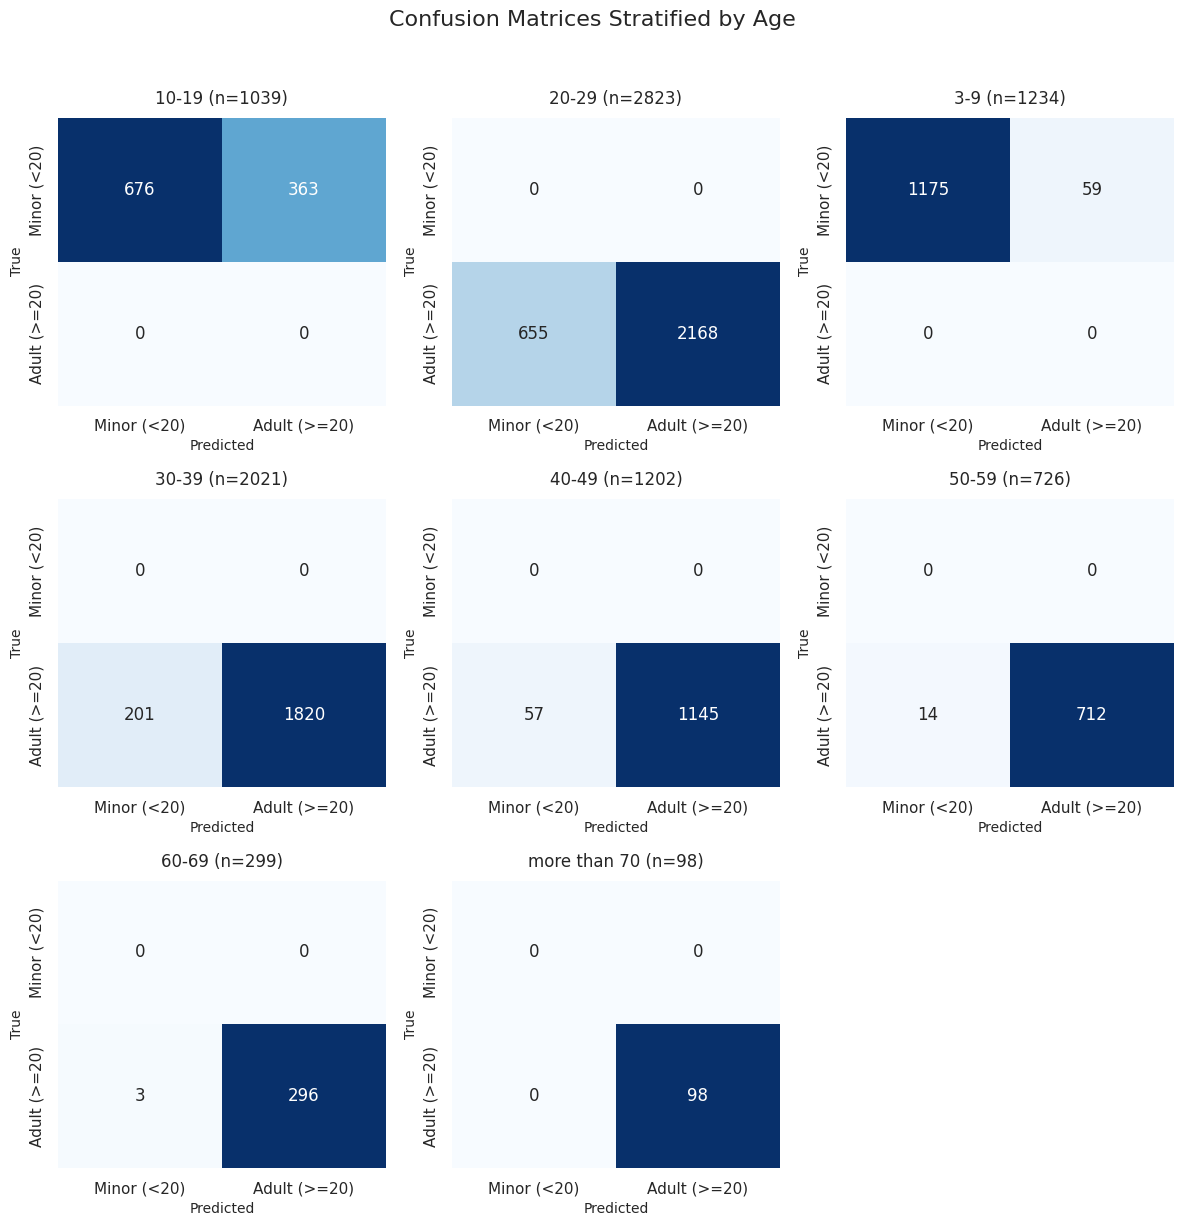

In [ ]:
# ─── Execution ────────────────────────────────────────────────────────
# Assuming 'results_df' is your DataFrame containing test set predictions
demographics_to_audit = ['gender', 'race', 'age']

print("Generating Bar Charts...")
plot_demographic_bar_charts(results_df, demographics_to_audit)

print("\nGenerating Stratified Confusion Matrices...")
for demo in demographics_to_audit:
    plot_subgroup_confusion_matrices(results_df, demographic_col=demo)

In [ ]:
def generate_ethnicity_stats_table(df):
    """
    Generates a structured summary table showing Accuracy, FPR, and FNR
    broken down by ethnicity.
    """
    # Map numerical race codes to text labels if they aren't already string values
    race_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Other'}

    # Ensure working vectors are cleanly isolated
    y_true = df['over_20'].astype(int).values
    y_pred = df['pred_over_20'].astype(int).values
    r_labels = df['race'].map(race_map).fillna(df['race']).values

    stats_list = []
    unique_races = np.unique(r_labels)

    for race in unique_races:
        mask = (r_labels == race)
        if mask.sum() == 0:
            continue

        y_true_sub = y_true[mask]
        y_pred_sub = y_pred[mask]

        # Extract confusion matrix components safely
        # Labels=[0, 1] maps 0 to Minor and 1 to Adult
        tn, fp, fn, tp = confusion_matrix(y_true_sub, y_pred_sub, labels=[0, 1]).ravel()

        # Calculate Rates
        total = tn + fp + fn + tp
        accuracy = (tp + tn) / total if total > 0 else 0

        # False Positive Rate: Minors incorrectly flagged as Adults
        fpr = fp / (tn + fp) if (tn + fp) > 0 else 0

        # False Negative Rate: Adults incorrectly flagged as Minors
        fnr = fn / (tp + fn) if (tp + fn) > 0 else 0

        stats_list.append({
            'Ethnicity': race,
            'Sample Size (n)': int(total),
            'Accuracy (%)': round(accuracy * 100, 2),
            'FPR: Minor as Adult (%)': round(fpr * 100, 2),
            'FNR: Adult as Minor (%)': round(fnr * 100, 2)
        })

    # Convert list to structured Pandas DataFrame
    summary_table = pd.DataFrame(stats_list)
    return summary_table

# ─── Execution Pass ─────────────────────────────────────────────────────
# Pass your test results dataframe into the function
ethnicity_audit_df = generate_ethnicity_stats_table(results_df)

# Display the clean markdown table representation directly in your notebook
from IPython.display import display, HTML
print("                                 DenseNet121 Stats by Ethnicity")
display(HTML(ethnicity_audit_df.to_html(index=False)))

                                 DenseNet121 Stats by Ethnicity


Ethnicity,Sample Size (n),Accuracy (%),FPR: Minor as Adult (%),FNR: Adult as Minor (%)
Black,1326,84.24,13.14,16.94
East Asian,1322,79.27,16.18,22.30
Indian,1280,86.48,16.09,12.67
Latino_Hispanic,1445,89.20,19.83,7.82
Middle Eastern,1032,89.83,22.09,7.79
Southeast Asian,1201,81.10,15.73,20.14
White,1836,88.67,29.59,7.21


<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_849/2072184558.py:35: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('Predicted Probability of Being an Adult ($\geq 20$)', fontsize=12)
/tmp/ipykernel_849/2072184558.py:43: SyntaxWarning: invalid escape sequence '\g'
  labels = ['Minor ($< 20$)', 'Adult ($\geq 20$)']


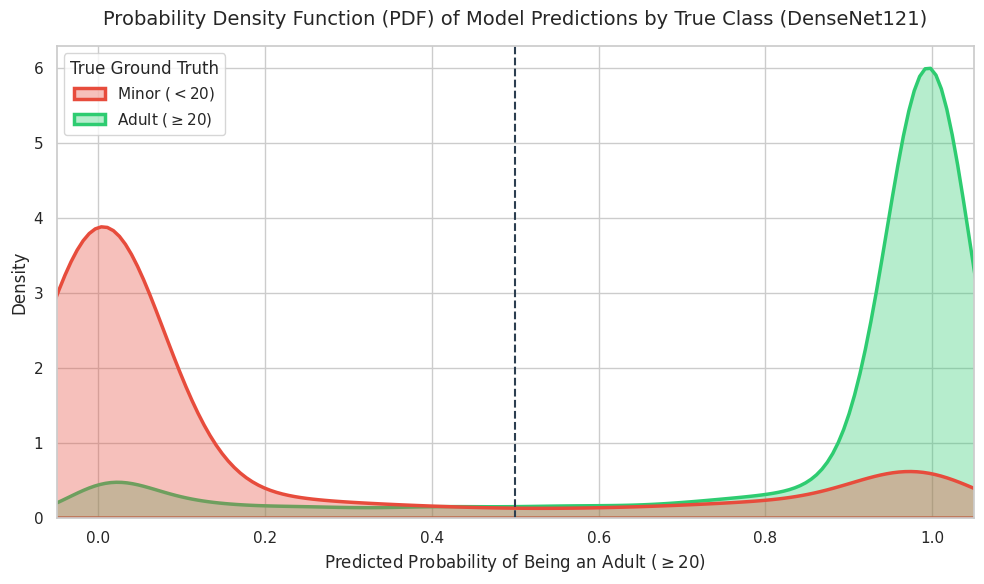

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the aesthetic theme
sns.set_theme(style="whitegrid")

# 2. Set up the canvas using subplots
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot the continuous probability density distributions
# 'common_norm=False' normalizes each class independently so sample size imbalances don't distort the curves
sns.kdeplot(
    data=results_df,
    x='probability',
    hue='over_20',
    fill=True,
    common_norm=False,
    palette=['#e74c3c', '#2ecc71'],
    alpha=0.35,
    linewidth=2.5,
    ax=ax
)

# 4. Add a vertical line at the default classification threshold
ax.axvline(
    x=0.5,
    color='#2c3e50',
    linestyle='--',
    linewidth=1.5,
    label='Classification Threshold ($0.5$)'
)

# 5. Scientific formatting and labeling
ax.set_title('Probability Density Function (PDF) of Model Predictions by True Class (DenseNet121)', fontsize=14, pad=15)
ax.set_xlabel('Predicted Probability of Being an Adult ($\geq 20$)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-0.05, 1.05)

# Update legend text safely to show clear human-readable categories
leg = ax.get_legend()
if leg:
    leg.set_title('True Ground Truth')
    labels = ['Minor ($< 20$)', 'Adult ($\geq 20$)']
    for t, label in zip(leg.texts, labels):
        t.set_text(label)

plt.tight_layout()

# 6. Save the graphic locally
plt.savefig('probability_density_plot.png', dpi=300, bbox_inches='tight')

# Visualisation

In [ ]:
# ─────────────────────────────────────────────
# GRAD-CAM
# ─────────────────────────────────────────────

class GradCAM:
    """
    Hooks into a target conv layer, runs a forward pass,
    then backprops a scalar target to get gradient-weighted
    activation maps.
    """
    def __init__(self, chosen_model, target_layer):
        self.chosen_model        = chosen_model
        self.activations  = None
        self.gradients    = None

        # forward hook — store activations
        self._fwd = target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, "activations", out.detach())
        )
        # backward hook — store gradients
        self._bwd = target_layer.register_full_backward_hook(
            lambda m, grad_in, grad_out: setattr(self, "gradients", grad_out[0].detach())
        )

    def generate(self, input_tensor, target="over_20"):
        """
        target: "over_20"
        Returns a (H, W) numpy heatmap in [0, 1].
        """
        self.chosen_model.eval()
        input_tensor = input_tensor.unsqueeze(0)   # (1, C, H, W)
        input_tensor.requires_grad_()

        over_20_logit = self.chosen_model(input_tensor)

        self.chosen_model.zero_grad()

        scalar = over_20_logit.squeeze()


        scalar.backward()

        # global average pool gradients over spatial dims  → (C,)
        weights = self.gradients.squeeze(0).mean(dim=(1, 2))

        # weighted combination of activation maps → (H, W)
        cam = (weights[:, None, None] * self.activations.squeeze(0)).sum(dim=0)
        #cam = F.relu(cam)   # keep only positive contributions

        # normalise to [0, 1]
        #cam -= cam.min()
        #if cam.max() > 0:
            #cam /= cam.max()

        return cam.cpu().numpy()

    def remove_hooks(self):
        self._fwd.remove()
        self._bwd.remove()

In [ ]:
# ─────────────────────────────────────────────
# FIND 3 HIGHEST LOSS VALIDATION IMAGES
# ─────────────────────────────────────────────

def get_highest_loss_samples(chosen_model, val_df, transform, device, n=3):
    """
    Runs inference over the full val set, computes per-sample combined loss,
    returns the n highest loss samples as a list of dicts.
    """
    chosen_model.eval()
    bce = torch.nn.BCEWithLogitsLoss(reduction="none")
    records = []

    for idx in range(len(val_df)):
        row      = val_df.iloc[idx]
        img_path = row["file"] # Corrected column name from "image" to "filepath"
        class_true = torch.tensor([row["over_20"]], dtype=torch.float32).to(device)


        image = Image.open(img_path).convert("RGB")
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            # Corrected to unpack single logit from Over20ResNet34 model
            over_20_logit = chosen_model(tensor)

        loss_over_20 = bce(over_20_logit.squeeze(), class_true.squeeze()).item() # Renamed and used correct logit
        loss     = loss_over_20 # Corrected loss assignment

        records.append({
            "idx":       idx,
            "img_path":  img_path,
            "filename":  row["file"],
            "over_20_true":  row["over_20"], # Fixed syntax error, renamed key
            "over_20_pred":  float(torch.sigmoid(over_20_logit).item()), # Renamed key
            "loss":      loss,
            "tensor":    transform(image),   # store for Grad-CAM
            "pil":       image,
        })

    records.sort(key=lambda x: x["loss"], reverse=True)
    return records[:n]

def get_highest_loss_samples_minor(chosen_model, val_df, transform, device, n=3):
    """
    Runs inference over the full val set, computes per-sample combined loss,
    returns the n highest loss samples as a list of dicts.
    """
    chosen_model.eval()
    bce = torch.nn.BCEWithLogitsLoss(reduction="none")
    records = []

    for idx in range(len(val_df)):
        row      = val_df.iloc[idx]
        img_path = row["file"] # Corrected column name from "image" to "filepath"
        class_true = torch.tensor([row["over_20"]], dtype=torch.float32).to(device)


        image = Image.open(img_path).convert("RGB")
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            # Corrected to unpack single logit from Over20ResNet34 model
            over_20_logit = chosen_model(tensor)

        loss_over_20 = bce(over_20_logit.squeeze(), class_true.squeeze()).item() # Renamed and used correct logit
        loss     = loss_over_20 # Corrected loss assignment

        if int(row["over_20"]) == 0:
          records.append({
              "idx":       idx,
              "img_path":  img_path,
              "filename":  row["file"],
              "over_20_true":  row["over_20"], # Fixed syntax error, renamed key
              "over_20_pred":  float(torch.sigmoid(over_20_logit).item()), # Renamed key
              "loss":      loss,
              "tensor":    transform(image),   # store for Grad-CAM
              "pil":       image,
          })

    records.sort(key=lambda x: x["loss"], reverse=True)
    return records[:n]

# ─────────────────────────────────────────────
# FIND 3 LOWEST LOSS VALIDATION IMAGES
# ─────────────────────────────────────────────

def get_lowest_loss_samples(chosen_model, val_df, transform, device, n=3):
    """
    Runs inference over the full val set, computes per-sample combined loss,
    returns the n highest loss samples as a list of dicts.
    """
    chosen_model.eval()
    bce = torch.nn.BCEWithLogitsLoss(reduction="none")
    records = []

    for idx in range(len(val_df)):
        row      = val_df.iloc[idx]
        img_path = row["file"] # Corrected column name from "image" to "filepath"
        class_true = torch.tensor([row["over_20"]], dtype=torch.float32).to(device)


        image = Image.open(img_path).convert("RGB")
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            # Corrected to unpack single logit from Over20ResNet34 model
            over_20_logit = chosen_model(tensor)

        loss_over_20 = bce(over_20_logit.squeeze(), class_true.squeeze()).item() # Renamed and used correct logit
        loss     = loss_over_20 # Corrected loss assignment

        records.append({
            "idx":       idx,
            "img_path":  img_path,
            "filename":  row["file"],
            "over_20_true":  row["over_20"], # Fixed syntax error, renamed key
            "over_20_pred":  float(torch.sigmoid(over_20_logit).item()), # Renamed key
            "loss":      loss,
            "tensor":    transform(image),   # store for Grad-CAM
            "pil":       image,
        })

    records.sort(key=lambda x: x["loss"], reverse=True)
    return records[-n:]

def get_lowest_loss_samples_adult(chosen_model, val_df, transform, device, n=3):
    """
    Runs inference over the full val set, computes per-sample combined loss,
    returns the n highest loss samples as a list of dicts.
    """
    chosen_model.eval()
    bce = torch.nn.BCEWithLogitsLoss(reduction="none")
    records = []

    for idx in range(len(val_df)):
        row      = val_df.iloc[idx]
        img_path = row["file"] # Corrected column name from "image" to "filepath"
        class_true = torch.tensor([row["over_20"]], dtype=torch.float32).to(device)


        image = Image.open(img_path).convert("RGB")
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            # Corrected to unpack single logit from Over20ResNet34 model
            over_20_logit = chosen_model(tensor)

        loss_over_20 = bce(over_20_logit.squeeze(), class_true.squeeze()).item() # Renamed and used correct logit
        loss     = loss_over_20 # Corrected loss assignment

        if int(row["over_20"]) == 1:
          records.append({
              "idx":       idx,
              "img_path":  img_path,
              "filename":  row["file"],
              "over_20_true":  row["over_20"], # Fixed syntax error, renamed key
              "over_20_pred":  float(torch.sigmoid(over_20_logit).item()), # Renamed key
              "loss":      loss,
              "tensor":    transform(image),   # store for Grad-CAM
              "pil":       image,
          })

    records.sort(key=lambda x: x["loss"], reverse=True)
    return records[-n:]

# ─────────────────────────────────────────────
# PLOT HEATMAPS
# ─────────────────────────────────────────────

def plot_gradcam(chosen_model, samples, target_layer, device, target="over_20", label="Model"):
    gradcam = GradCAM(chosen_model, target_layer)
    n       = len(samples)
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    if n == 1:
        axes = [axes]

    for i, sample in enumerate(samples):
        tensor = sample["tensor"].to(device)
        cam    = gradcam.generate(tensor, target=target)

        img_np = np.array(sample["pil"].resize((224, 224)))
        if img_np.ndim == 2:
            img_rgb = np.stack([img_np / 255.0] * 3, axis=-1)
        else:
            img_rgb = img_np / 255.0

        cam_resized = np.array(
            Image.fromarray(cam).resize((224, 224), Image.BILINEAR)
        )

        # heatmap overlay
        vmax    = np.abs(cam_resized).max()
        cam_norm = (cam_resized + vmax) / (2 * vmax)   # shift to [0,1] for colormap
        heatmap = cm.RdBu_r(cam_norm)[..., :3]
        overlay = 0.6 * heatmap + 0.4 * img_rgb

        # Corrected labels for over_20 classification
        true_label = "Adult" if sample["over_20_true"] == 1 else "Minor"
        pred_label = "Adult" if sample["over_20_pred"] >= 0.5 else "Minor"

        axes[i][0].imshow(img_rgb) # Removed cmap="gray" as image is RGB
        axes[i][0].set_title(
            f"{sample['img_path']}\n" # Changed 'filepath' to 'img_path'
            f"True: {true_label}\n" # Removed BMI
            f"Pred: {pred_label} ({sample['over_20_pred']:.2f})\n" # Removed BMI
            f"Loss: {sample['loss']:.4f}",
            fontsize=8
        )
        axes[i][0].axis("off")

        axes[i][1].imshow(overlay)
        axes[i][1].set_title(f"Grad-CAM ({target} head)", fontsize=8)
        axes[i][1].axis("off")

    plt.suptitle(f"Top {n} Highest Loss Validation Samples — {label} ({target})", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"gradcam_{target}_top{n}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> gradcam_{target}_top{n}.png")

    gradcam.remove_hooks()

## DenseNet121

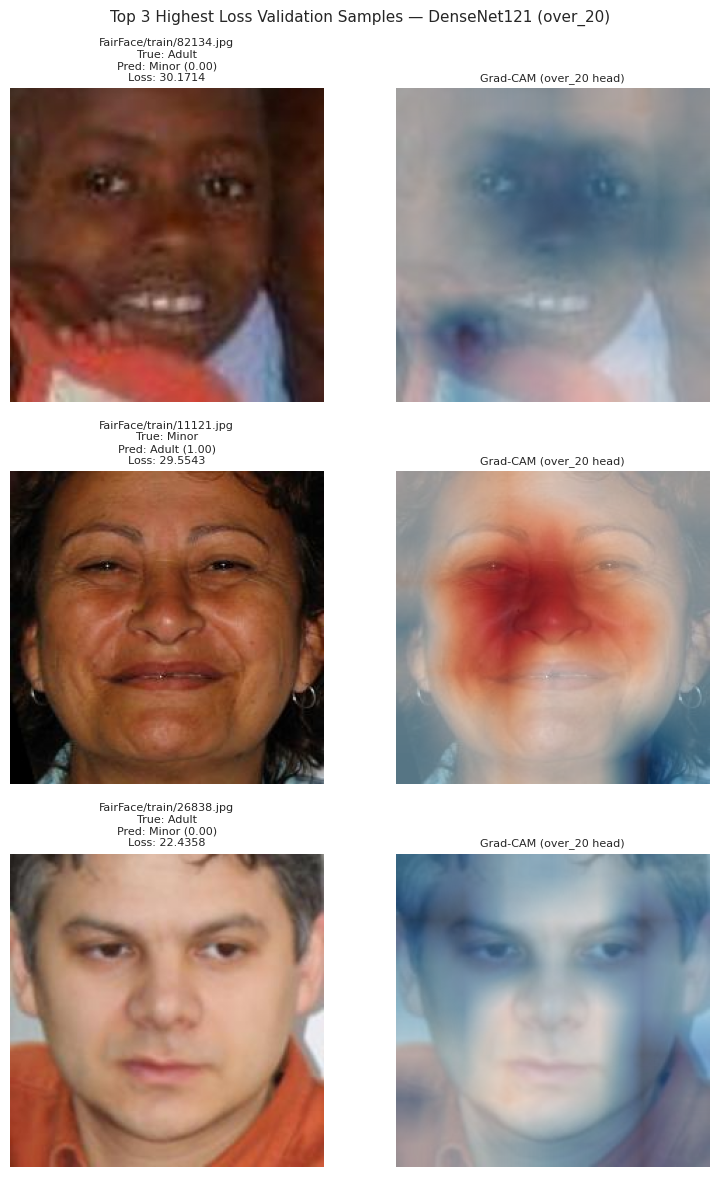

Saved -> gradcam_over_20_top3.png


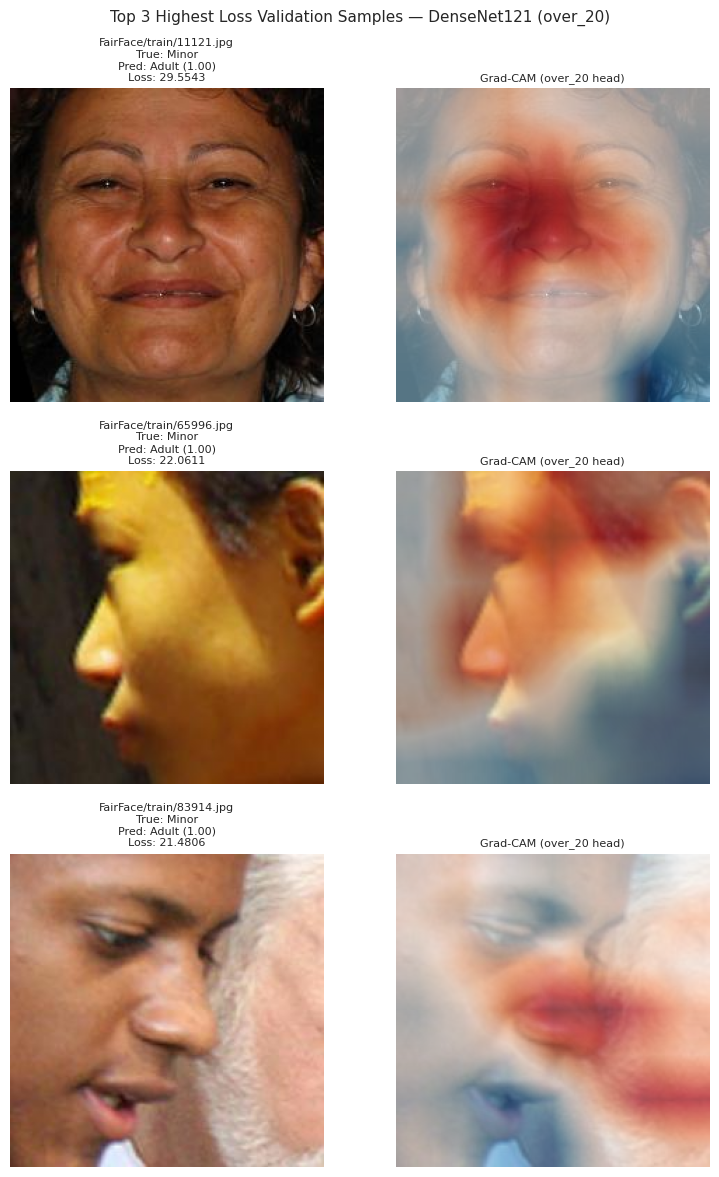

Saved -> gradcam_over_20_top3.png


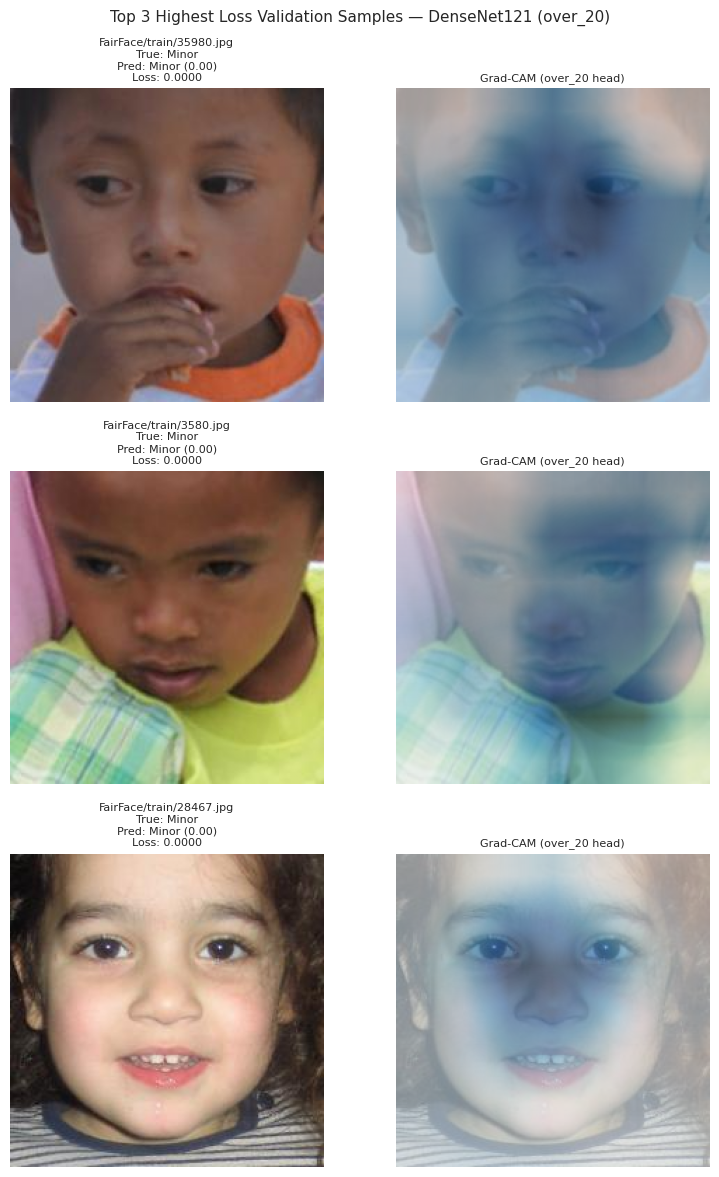

Saved -> gradcam_over_20_top3.png


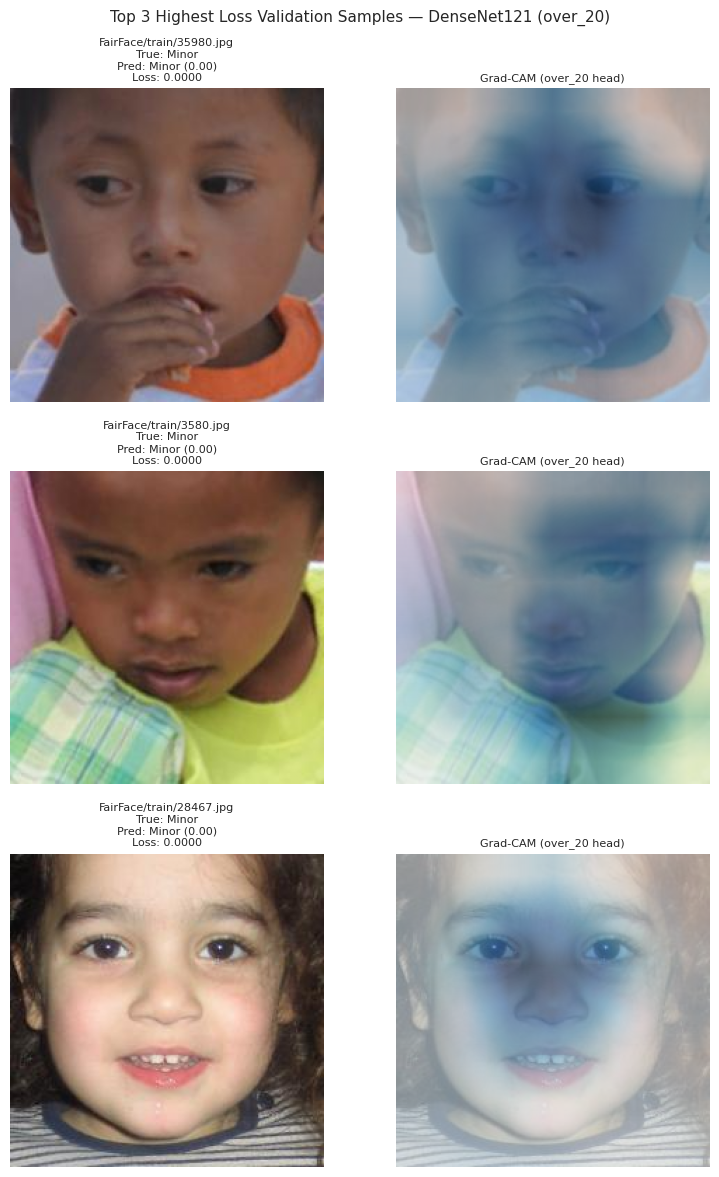

Saved -> gradcam_over_20_top3.png


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate UTKFaceDataset to get the transform
val_ds = FairFaceDataset(val_df) # Use the downsampled validation set
val_transform = val_ds.transform

target_layer = model_rn.backbone[-2]   # <-- adjust per model (e.g., layer4[-1].conv3)

highest_loss_samples = get_highest_loss_samples(model_rn, val_df, val_transform, DEVICE, n=3)
highest_loss_minor_samples = get_highest_loss_samples_minor(model_rn, val_df, val_transform, DEVICE, n=3)
lowest_loss_samples = get_lowest_loss_samples(model_rn, val_df, val_transform, DEVICE, n=3)
lowest_loss_adult_samples = get_lowest_loss_samples_adult(model_rn, val_df, val_transform, DEVICE, n=3)


plot_gradcam(model_rn, highest_loss_samples, target_layer, DEVICE, target="over_20", label="DenseNet121")
plot_gradcam(model_rn, highest_loss_minor_samples, target_layer, DEVICE, target="over_20", label="DenseNet121")
plot_gradcam(model_rn, lowest_loss_samples, target_layer, DEVICE, target="over_20", label="DenseNet121")
plot_gradcam(model_rn, lowest_loss_adult_samples, target_layer, DEVICE, target="over_20", label="DenseNet121")

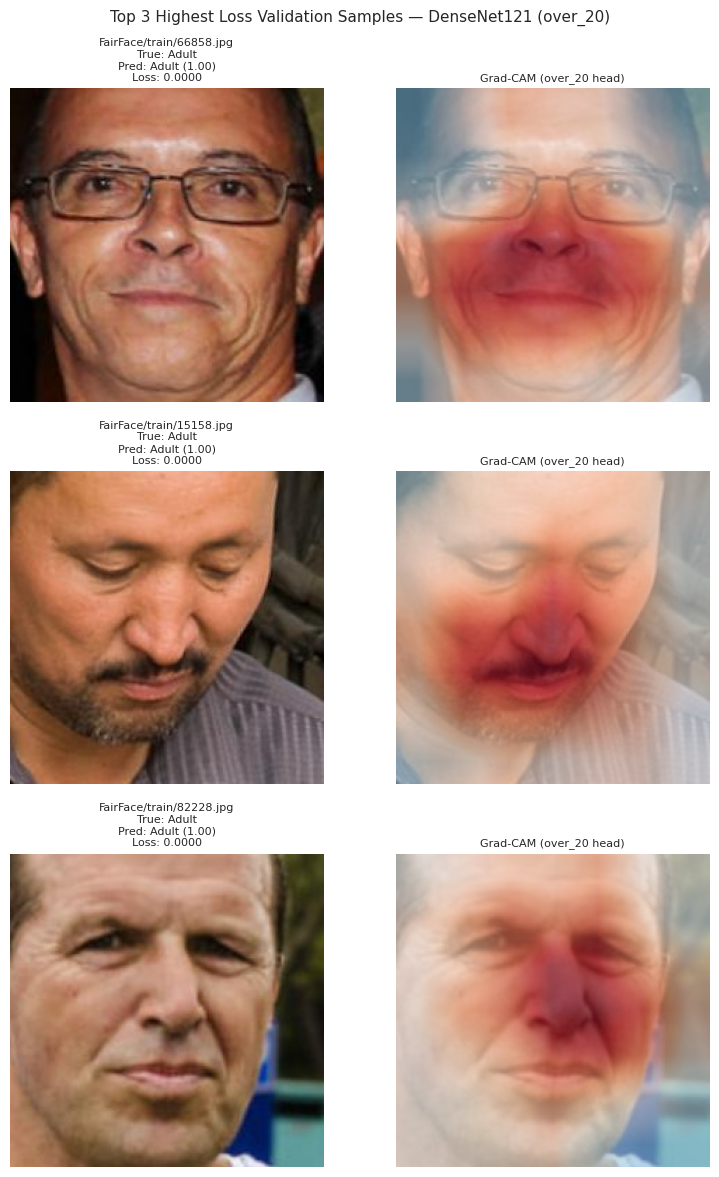

Saved -> gradcam_over_20_top3.png


In [ ]:
lowest_loss_adult_samples = get_lowest_loss_samples_adult(model_rn, val_df, val_transform, DEVICE, n=3)
plot_gradcam(model_rn, lowest_loss_adult_samples, target_layer, DEVICE, target="over_20", label="DenseNet121")

##ResNet

In [ ]:
model_rn = Over20ResNet34(dropout=0.4, freeze_backbone=False) # Start with empty, uninitialized weights

# 2. Define the execution device safely
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Load the weights dictionary file securely
# map_location ensures that if you saved on a GPU but are testing on a CPU, it shifts smoothly without crashing
model_path = 'best_over18_resnet34.pt'
state_dict = torch.load(model_path, map_location=device, weights_only=True)

# 4. Inject the loaded weights into your structural skeleton
model_rn.load_state_dict(state_dict)

# 5. Push the unified model to your device and lock it in evaluation mode
model_rn = model_rn.to(device)

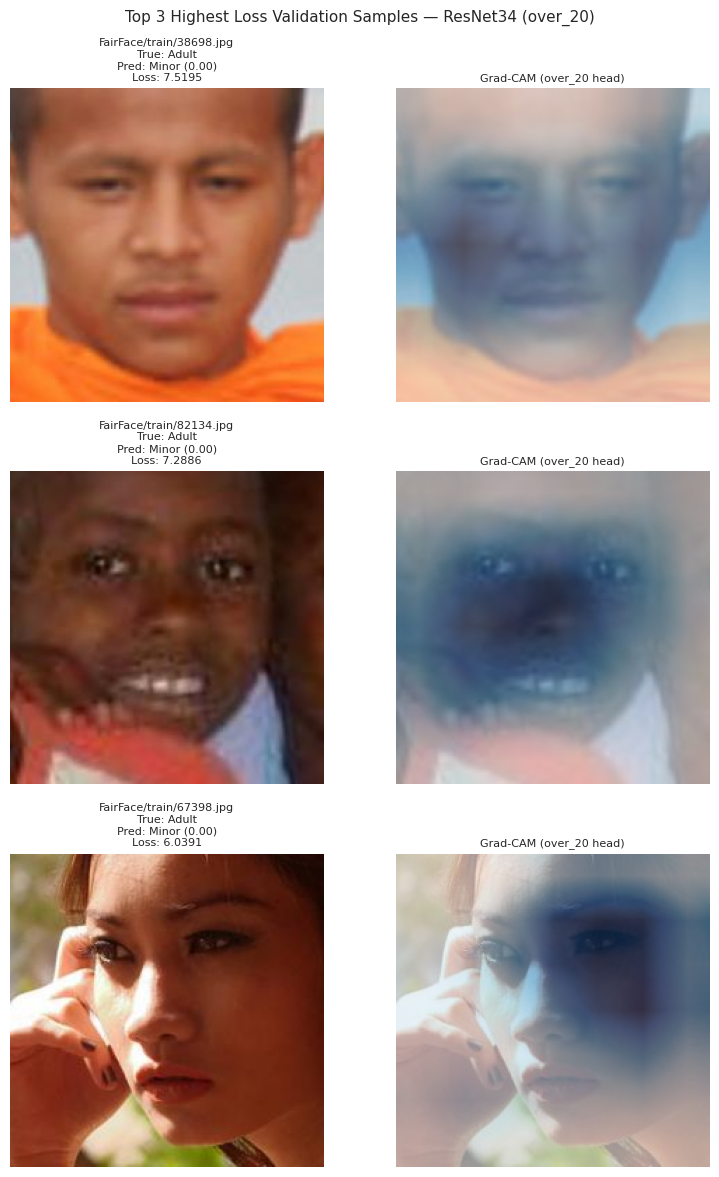

Saved -> gradcam_over_20_top3.png


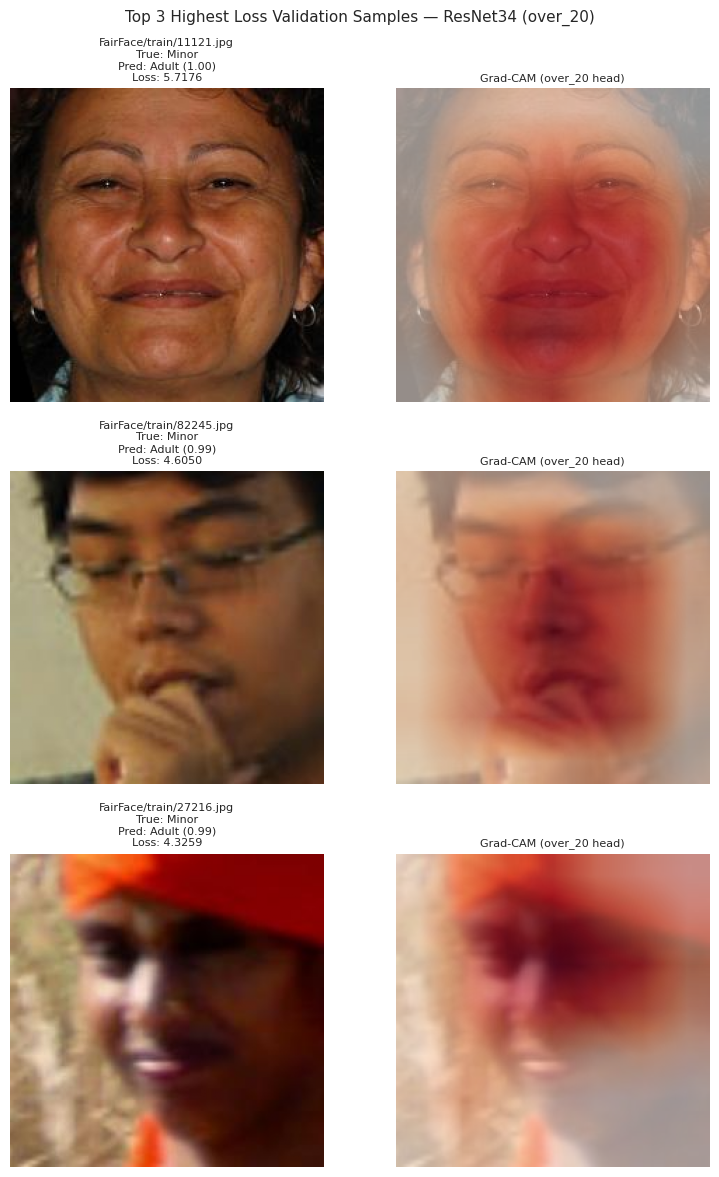

Saved -> gradcam_over_20_top3.png


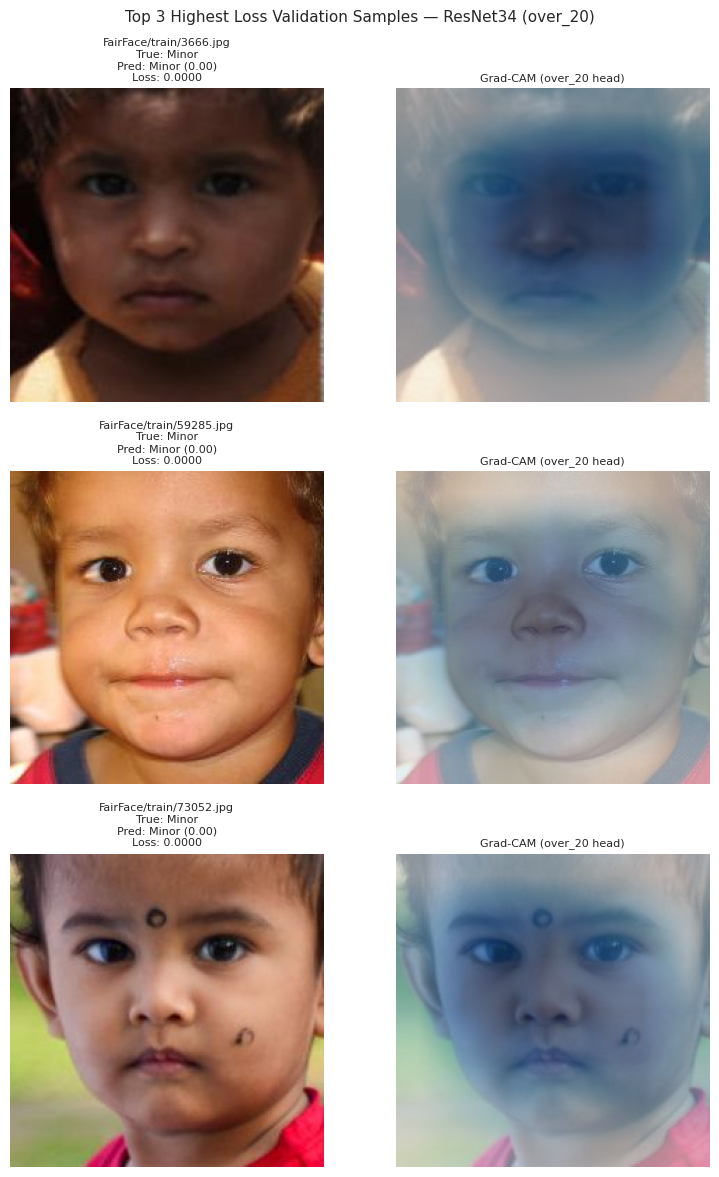

Saved -> gradcam_over_20_top3.png


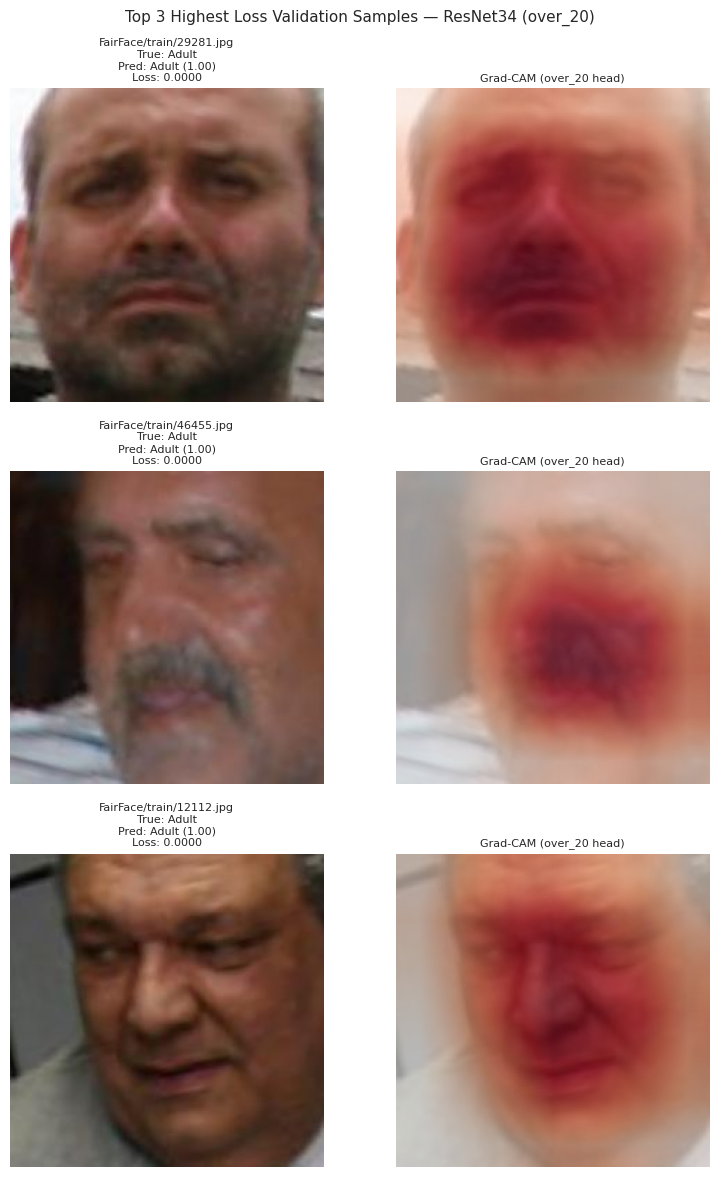

Saved -> gradcam_over_20_top3.png


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate UTKFaceDataset to get the transform
val_ds = FairFaceDataset(val_df) # Use the downsampled validation set
val_transform = val_ds.transform

target_layer = model_rn.backbone[-2]   # <-- adjust per model (e.g., layer4[-1].conv3)

highest_loss_samples = get_highest_loss_samples(model_rn, val_df, val_transform, DEVICE, n=3)
highest_loss_minor_samples = get_highest_loss_samples_minor(model_rn, val_df, val_transform, DEVICE, n=3)
lowest_loss_samples = get_lowest_loss_samples(model_rn, val_df, val_transform, DEVICE, n=3)
lowest_loss_adult_samples = get_lowest_loss_samples_adult(model_rn, val_df, val_transform, DEVICE, n=3)


plot_gradcam(model_rn, highest_loss_samples, target_layer, DEVICE, target="over_20", label="ResNet34")
plot_gradcam(model_rn, highest_loss_minor_samples, target_layer, DEVICE, target="over_20", label="ResNet34")
plot_gradcam(model_rn, lowest_loss_samples, target_layer, DEVICE, target="over_20", label="ResNet34")
plot_gradcam(model_rn, lowest_loss_adult_samples, target_layer, DEVICE, target="over_20", label="ResNet34")